# Do Dynamic Electricity Price Signals Make Dynamic Homes? Lessons from Norway
Supplementary Plots and Explanations

### 1. Data Sources

The analysis is based on the following datasets:

- **Household Consumption:** Hourly time-series data per bidding zone  
  (Elhub Data Catalog: https://elhub.no/data-og-innsikt/datakatalog)

- **Electricity Prices:** Hourly spot prices from the Norwegian electricity market

- **Temperature:** Population-weighted mean temperature derived from ERA5 reanalysis data, spatially aggregated by bidding zone using population data at 1 km resolution

These datasets are combined to capture both economic and environmental drivers of electricity demand.
The table below shows the summary of the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings

# Suppress FutureWarnings to maintain clean output for production reports
warnings.filterwarnings("ignore", category=FutureWarning)

# Global visualization settings for academic/reporting standards
plt.rcParams.update({
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'Arial'
})

# --- VISUAL IDENTITIES ---
# Maintain consistent color coding for the three regulatory regimes across all plots
period_palette = {
    'MonthlySubsidy': '#1f77b4', # Industry standard Blue
    'HourlySubsidy': '#ff7f0e',  # High-contrast Orange
    'NorwayPrice': '#2ca02c'      # 'Norgespris' Green
}

# Define zones (NO1-NO5) and a perceptually uniform color palette for mapping
zones = ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']
zone_palette = sns.color_palette("viridis", n_colors=len(zones))

In [2]:
# Load raw time-series data
df = pd.read_csv("Data.csv", sep=",")

# Standardize temporal index to UTC for cross-zone alignment
df['start_date'] = pd.to_datetime(df['start_date'], utc=True)
df = df.set_index('start_date').sort_index()

# Quality Control: Remove records missing core variables
df = df.dropna(subset=['Price', 'Consumption'])

# --- 1. Define Policy Cutoffs (Natural Experiment Transitions) ---
# Transition from Monthly to Hourly subsidy
cutoff1 = pd.Timestamp("2023-09-01", tz="UTC") 
# Transition to NorgePrice regime
cutoff2 = pd.Timestamp("2025-10-01", tz="UTC") 

# --- 2. Labeling Regimes ---
# Categorize data points into their respective policy windows
conditions = [
    (df.index < cutoff1),
    (df.index >= cutoff1) & (df.index < cutoff2),
    (df.index >= cutoff2)
]
choices = ['MonthlySubsidy', 'HourlySubsidy', 'NorwayPrice']
df['Period'] = np.select(conditions, choices, default='Unknown')

# --- 3. Feature Engineering ---
# Normalize by household count to enable 'Apples-to-Apples' comparison between 
# high-population zones (NO1) and low-population zones (NO4).
df['Consumption_per_household'] = df['Consumption'] / df['NoMeasured']

# Backup processed state before performing aggregations
df_base = df.copy()

# --- 4. Data Summary ---
summary_df = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Start Time",
        "End Time",
        "Time Span (days)",
        "Number of Columns",
        "Unique Hours",
        "Columns"
    ],
    "Value": [
        len(df),
        df.index.min(),
        df.index.max(),
        (df.index.max() - df.index.min()).days,
        df.shape[1],
        df.index.nunique(),
        ", ".join([
            "Electricity Consumption",
            "Number of Households",
            "Price",
            "Zone",
            "Population Weighted Mean Temperature (Zone)",
            "Period",
            "Consumption per Household"
        ])
    ]
})

print("## Data Description\n")
print(summary_df.to_markdown(index=False))


result = df.groupby("Period").apply(lambda x: x.index.nunique()).reset_index()
result.columns = ["Period", "Unique Hours"]

print("## Rows per regulatory regime \n")
print(result.to_markdown(index=False))


## Data Description

| Metric            | Value                                                                                                                                      |
|:------------------|:-------------------------------------------------------------------------------------------------------------------------------------------|
| Total Rows        | 182400                                                                                                                                     |
| Start Time        | 2022-01-01 00:00:00+00:00                                                                                                                  |
| End Time          | 2026-02-28 23:00:00+00:00                                                                                                                  |
| Time Span (days)  | 1519                                                                                                                                       |
|

### 2. Norway Bidding Zones: Population and Temperature

The figure below illustrates Norway’s electricity bidding zones, along with population distribution and population-weighted temperature.

Population data at 1 km resolution are projected onto temperature data (approximately 9 km resolution) and aggregated at the zone level. These projections are used to compute representative temperature measures for each zone.


The table summarizes the number of Households in each zone during 2022. The Number of households is a dynamic data that varies as houses are added. 


In [3]:
# Select the columns and rename
df_tail = df[['Zone', 'NoMeasured']].tail().rename(columns={'NoMeasured': 'No of Households'})
# Reset index so it does not display
df_tail = df_tail.reset_index(drop=True)
# Display as Markdown table (or in Jupyter it will render nicely)
print(df_tail.to_markdown(index=False))
df_tail.sum()

| Zone   |   No of Households |
|:-------|-------------------:|
| NO1    |            1118075 |
| NO2    |             630506 |
| NO3    |             409408 |
| NO4    |             245962 |
| NO5    |             259421 |


Zone                NO1NO2NO3NO4NO5
No of Households            2663372
dtype: object


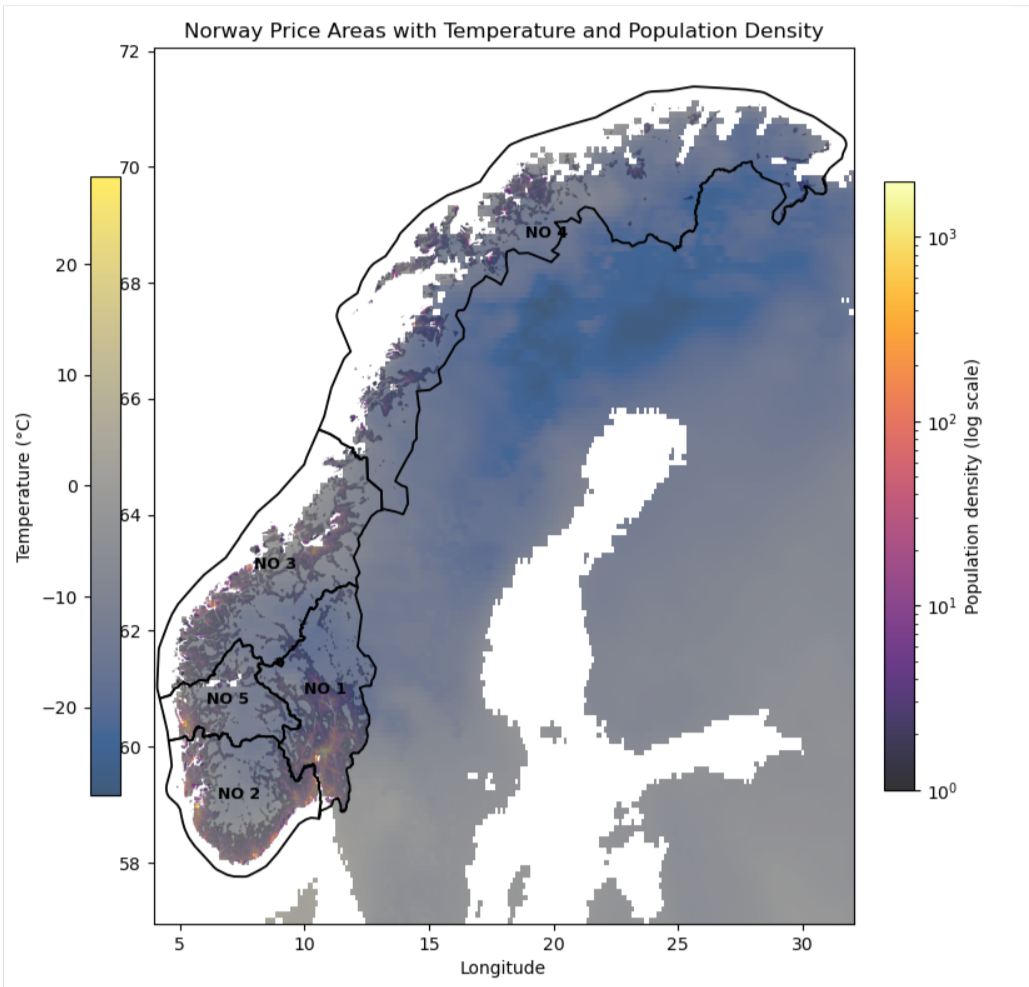

### 4. Consumption per Household and Average Price Profiles by Zone and Period

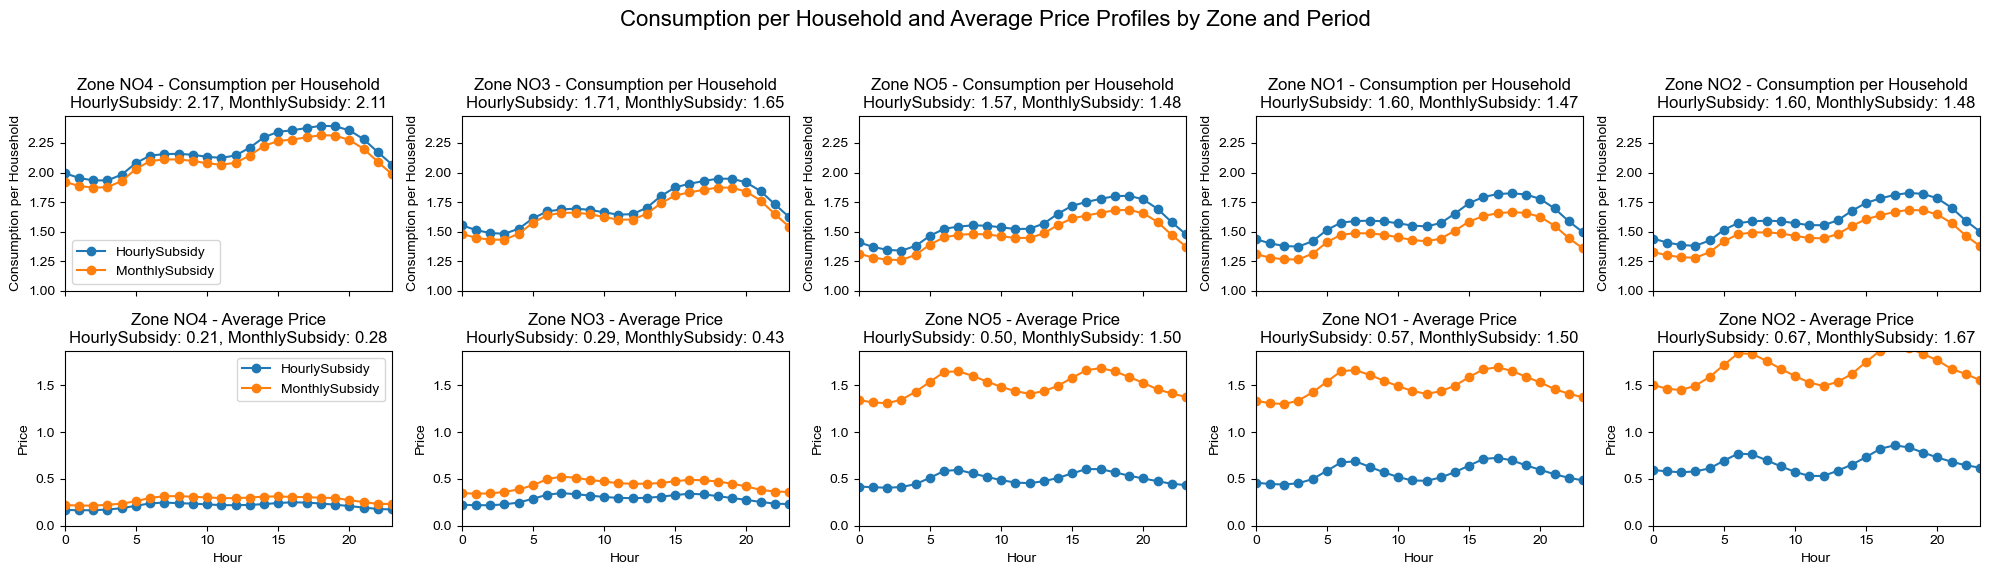

Average Daily Household consumption in whole of Norway for whole dataset: Consumption_per_household    40.529449
dtype: float64
Average hourly Spot Market Price in whole of Norway for whole dataset: Price    0.725685
dtype: float64


Consumption_per_household    1.688727
Price                        0.725685
dtype: float64

In [4]:
df=df_base[df_base.index < cutoff2]
df=df.copy()
df['hour'] = df.index.hour

periods = sorted(df['Period'].unique())
colors = sns.color_palette("tab10", n_colors=len(periods))

# Compute average price per zone (across all hours and periods)
zone_avg_price = df.groupby('Zone')['Price'].mean().sort_values()
zones_ordered = zone_avg_price.index.tolist()

# Determine y-axis limits for consistency
max_consumption = df.groupby(['Zone','hour'])['Consumption_per_household'].mean().max()
max_price = df.groupby(['Zone','hour'])['Price'].mean().max()

fig, axes = plt.subplots(2, len(zones_ordered), figsize=(4*len(zones_ordered), 6), sharex=True, sharey=False)
fig.suptitle('Consumption per Household and Average Price Profiles by Zone and Period', fontsize=16)

for col, zone in enumerate(zones_ordered):
    df_zone = df[df['Zone'] == zone]
    
    # Top row: Consumption per household
    ax1 = axes[0, col] if len(zones_ordered) > 1 else axes[0]
    means_consumption = []  # store mean for each period
    for i, period in enumerate(periods):
        df_period = df_zone[df_zone['Period'] == period]
        avg_consumption = df_period.groupby('hour')['Consumption_per_household'].mean()
        avg_consumption.plot(ax=ax1, label=period, color=colors[i], marker='o')
        means_consumption.append(f"{period}: {avg_consumption.mean():.2f}")
    
    # Display all-period means in the title
    ax1.set_title(f'Zone {zone} - Consumption per Household\n' + ', '.join(means_consumption))
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Consumption per Household')
    ax1.set_ylim(1, max_consumption*1.05)
    ax1.set_xlim(0,23)
    if col == 0:
        ax1.legend()
    
    # Bottom row: Average Price
    ax2 = axes[1, col] if len(zones_ordered) > 1 else axes[1]
    means_price = []  # store mean for each period
    for i, period in enumerate(periods):
        df_period = df_zone[df_zone['Period'] == period]
        avg_price = df_period.groupby('hour')['Price'].mean()
        avg_price.plot(ax=ax2, label=period, color=colors[i], marker='o')
        means_price.append(f"{period}: {avg_price.mean():.2f}")
    
    ax2.set_title(f'Zone {zone} - Average Price\n' + ', '.join(means_price))
    ax2.set_xlabel('Hour')
    ax2.set_ylabel('Price')
    ax2.set_ylim(0, max_price*1.4)
    ax2.set_xlim(0,23)
    if col == 0:
        ax2.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

CAve=df[['Consumption_per_household']].mean()*24
PAve=df[['Price']].mean()

print('Average Daily Household consumption in whole of Norway for whole dataset:',CAve)

print('Average hourly Spot Market Price in whole of Norway for whole dataset:',PAve)
df[['Consumption_per_household', 'Price']].mean()


### 5. Seasonal Variation: Winter vs. Summer
Electric space heating dominates electricity demand in Norway, making seasonality a key driver.
We define:
- **Winter:** November to March  
- **Summer:** May to September  


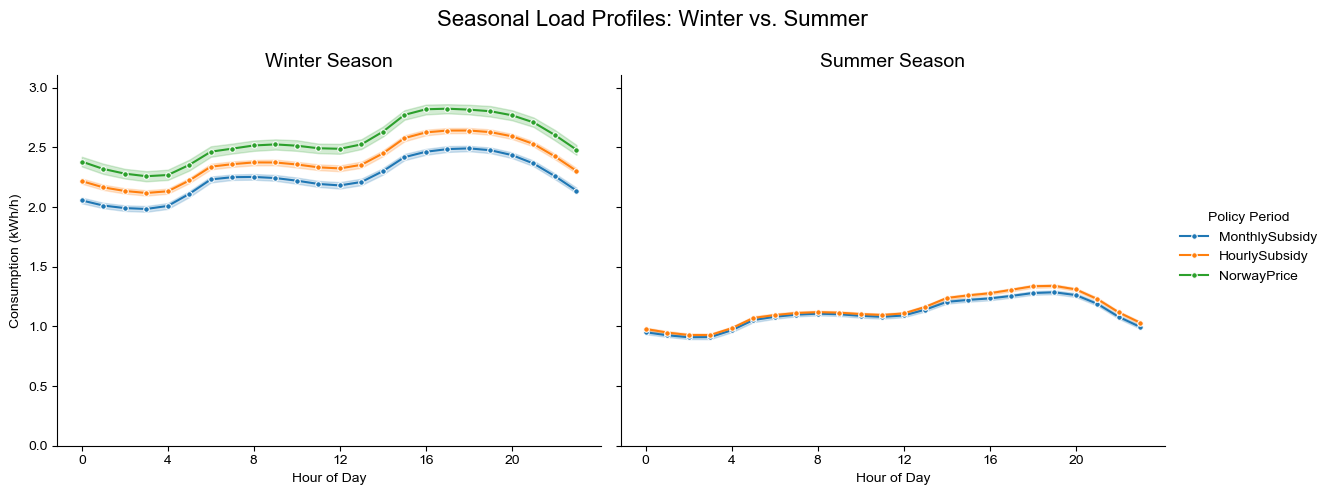

In [5]:
# 1. Define Seasons
# We exclude shoulder months (April, October) for a cleaner contrast
df_base['Month'] = df_base.index.month

conditions_season = [
    df_base['Month'].isin([11, 12, 1, 2, 3]),
    df_base['Month'].isin([5, 6, 7, 8, 9])
]
choices_season = ['Winter', 'Summer']

df_base['Season'] = np.select(conditions_season, choices_season, default='Shoulder')

# 2. Filtering for Analysis
df_season = df_base[df_base['Season'] != 'Shoulder'].copy()
df_season['hour'] = df_season.index.hour

# 3. Visualization
g = sns.FacetGrid(df_season, col="Season", hue="Period", 
                  palette=period_palette, height=5, aspect=1.2)

g.map(sns.lineplot, "hour", "Consumption_per_household", marker='o', markersize=4)

# Formatting
g.set_axis_labels("Hour of Day", "Consumption (kWh/h)")
g.set_titles("{col_name} Season", size=14)
g.add_legend(title="Policy Period")

# Standardize Y-axis across both plots for honest comparison
max_val = df_season.groupby(['Season', 'Period', 'hour'])['Consumption_per_household'].mean().max()
for ax in g.axes.flat:
    ax.set_ylim(0, max_val * 1.1)
    ax.set_xticks(range(0, 24, 4))

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Seasonal Load Profiles: Winter vs. Summer', fontsize=16)
plt.show()

During summer months, consumption appears more evenly distributed across pricing regimes.

Fluctuations in consumption are influenced by multiple factors, including:
- temperature variation
- electrification trends
- behavioral adaptation

The hypothesis that lower prices lead to overconsumption cannot be confirmed based on these observations alone.

In several zones, summer consumption has either declined or remained stable despite lower prices. Therefore, the analysis does not focus on absolute consumption levels, but instead on **load shifting behavior**.

In [6]:

def analyze_flatness(df, Top=5,plot=True):
    """
    Analyze consumption flatness vs. price variation with stratified quartiles.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must have index as datetime and columns: ['Consumption','Price','Zone','Period'].
    plot : bool
        If True, produces zone-wise plots.
    
    Returns
    -------
    comparison : pd.DataFrame
        Hourly fractions and mean price patterns (baseline vs high-var).
    flatness_table : pd.DataFrame
        CV and entropy-based flatness metrics per Zone.
    """
    # -----------------------------
    # 1. Copy df and extract date/hour
    # -----------------------------
    df = df.copy()
    df['date'] = df.index.normalize()   # keeps datetime64[ns], not plain date
    df['hour'] = df.index.hour

    # -----------------------------
    # 2. Hourly fraction per day per zone
    # -----------------------------
    df['DailyTotal'] = df.groupby(['Zone','date'])['Consumption'].transform('sum')
    df['HourlyFraction'] = df['Consumption'] / df['DailyTotal']

    # -----------------------------
    # 3. Compute daily price diff
    # -----------------------------
    df_daily = df.groupby(['Zone','Period','date'])['Price'].agg(['max','min']).reset_index()
    df_daily['PriceDiff'] = df_daily['max'] - df_daily['min']

    # -----------------------------
    # 4. Add Season and Weekend flag
    # -----------------------------
    def get_season(month):
        if month in [12,1,2]:
            return 'Winter'
        elif month in [3,4,5]:
            return 'Spring'
        elif month in [6,7,8]:
            return 'Summer'
        else:
            return 'Autumn'

    df_daily['Season'] = df_daily['date'].dt.month.apply(get_season)
    df_daily['is_weekend'] = df_daily['date'].dt.dayofweek >= 5

    # -----------------------------
    # 5. Assign stratified quartiles per Zone (balanced by Period, Season, Weekend)
    # -----------------------------
    def assign_quartiles_per_zone(df_daily):
        result = []
        for zone, zone_df in df_daily.groupby('Zone'):
            zone_df['PriceVariationLevel'] = zone_df.groupby(['Period','Season','is_weekend'])['PriceDiff'] \
                                                    .transform(lambda x: pd.qcut(x, q=4, labels=['Low','Medium','High','VeryHigh']))
            result.append(zone_df)
        return pd.concat(result)

    df_daily = assign_quartiles_per_zone(df_daily)

    # -----------------------------
    # 6. Merge back to hourly df
    # -----------------------------
    df = df.merge(df_daily[['Zone','Period','date','PriceVariationLevel']], 
                  on=['Zone','Period','date'], how='left')

    # -----------------------------
    # 7. Baseline and high-var profiles
    # -----------------------------
    baseline = df[df['PriceVariationLevel']=='Low'].groupby(['Zone','hour'])['HourlyFraction'].mean().reset_index()
    baseline = baseline.rename(columns={'HourlyFraction':'BaselineFraction'})

    high_var = df[df['PriceVariationLevel']=='VeryHigh'].groupby(['Zone','hour'])['HourlyFraction'].mean().reset_index()
    high_var = high_var.rename(columns={'HourlyFraction':'HighVarFraction'})

    # -----------------------------
    # 8. Mean hourly price on baseline vs high-var days
    # -----------------------------
    mean_price_baseline = df[df['PriceVariationLevel']=='Low'].groupby(['Zone','hour'])['Price'].mean().reset_index()
    mean_price_baseline = mean_price_baseline.rename(columns={'Price':'MeanHourlyPrice_Baseline'})

    mean_price_high_var = df[df['PriceVariationLevel']=='VeryHigh'].groupby(['Zone','hour'])['Price'].mean().reset_index()
    mean_price_high_var = mean_price_high_var.rename(columns={'Price':'MeanHourlyPrice_HighVar'})

    # -----------------------------
    # 9. Merge for comparison
    # -----------------------------
    comparison = baseline.merge(high_var, on=['Zone','hour'])
    comparison = comparison.merge(mean_price_baseline, on=['Zone','hour'])
    comparison = comparison.merge(mean_price_high_var, on=['Zone','hour'])

    # -----------------------------
    # 10. Normalize all curves per zone
    # -----------------------------
    zones = comparison['Zone'].unique()
    for zone in zones:
        mask = comparison['Zone'] == zone
        for col in ['BaselineFraction','HighVarFraction']:
            comparison.loc[mask, col] /= comparison.loc[mask, col].sum()

    # -----------------------------
    # 11. Compute flatness metrics
    # -----------------------------
        def pd_metric(p):
            return np.max(p) - np.min(p)
            
        def Top5C(p,Top):
            return np.sum(p[np.argsort(subset['BaselineFraction'].values)[-Top:]])*100

        def Top5P(p,q,Top):
            high_idx = np.argsort(q)[-Top:]
            return np.sum(p[high_idx])*100

    
        flatness_results = []
        for zone in zones:
            subset = comparison[comparison['Zone'] == zone]
            baseline_frac = subset['BaselineFraction'].values
            highvar_frac = subset['HighVarFraction'].values
            baseline_P = subset['MeanHourlyPrice_Baseline'].values
            highvar_P = subset['MeanHourlyPrice_HighVar'].values

            pd_baseline = pd_metric(subset['BaselineFraction'])
            pd_highvar = pd_metric(subset['HighVarFraction'])
            

            Top5P_baseline =  Top5P(baseline_frac, baseline_P,Top)  
            Top5P_highvar = Top5P( highvar_frac, highvar_P,Top) 
        
            seb_diff  = (((baseline_frac - highvar_frac)*CAve.values*highvar_P/highvar_P.sum()*24).sum())*30

            Top5C_baseline = Top5C(baseline_frac,Top)
            Top5C_highvar = Top5C(highvar_frac,Top)
        
        
            flatness_results.append({
                "Zone": zone,
                "pd_Diff": (pd_baseline - pd_highvar) / pd_baseline * 100,
                "Top5P_Diff": (Top5P_baseline- Top5P_highvar) ,
                "Top5C_Diff": (Top5C_baseline - Top5C_highvar)  ,
                "SEB_Diff": seb_diff,
            })
        
    flatness_table = pd.DataFrame(flatness_results)

    
    # -----------------------------
    # 12. Plots
    # -----------------------------
    if plot:
        for zone in zones:
            plt.figure(figsize=(12,6))
            sns.lineplot(data=comparison[comparison['Zone']==zone], x='hour', y='BaselineFraction', label='Baseline Fraction')
            sns.lineplot(data=comparison[comparison['Zone']==zone], x='hour', y='HighVarFraction', label='High-Var Fraction')
            plt.title(f'Zone {zone}: Normalized Hourly Patterns (Consumption & Price)')
            plt.xlabel('Hour of Day')
            plt.ylabel('Normalized Value (sum=1 per zone)')
            plt.grid(True)
            plt.legend()
            plt.show()

    return comparison, flatness_table, df


In [7]:
Top=5
comparison1, flatness_table1, df1= analyze_flatness(df,Top=Top, plot=False)
Ori=df1.copy()

In [8]:
def analyze_multiple_periods(dfs, period_labels,Top=5, plot=True):

    all_comparisons = []
    all_flatness = []
    all_tables = []

    # Loop over periods
    for df, period in zip(dfs, period_labels):
        comp, flat, tabs = analyze_flatness(df, Top=Top, plot=False)
        comp['Period'] = period
        flat['Period'] = period
        all_comparisons.append(comp)
        all_flatness.append(flat)
        all_tables.append(tabs)

    combined_comparison = pd.concat(all_comparisons, ignore_index=True)
    combined_flatness = pd.concat(all_flatness, ignore_index=True)
    combined_tables = pd.concat(all_tables, ignore_index=True)

    # -----------------------------
    # Plot: zones × periods (grid)
    # -----------------------------
    if plot:
        zones = combined_comparison['Zone'].unique()
        periods = period_labels

        fig, axes = plt.subplots(len(zones), len(periods), figsize=(8, 8), sharey=True)
        if len(zones) == 1:
            axes = np.array([axes])  # ensure 2D array
        if len(periods) == 1:
            axes = axes[:, np.newaxis]

        for i, zone in enumerate(zones):
            for j, period in enumerate(periods):
                subset = combined_comparison[
                    (combined_comparison['Zone'] == zone) &
                    (combined_comparison['Period'] == period)
                ]
                ax = axes[i, j]
                ax.plot(subset['hour'], subset['BaselineFraction'], label='LowVar', color='blue')
                ax.plot(subset['hour'], subset['HighVarFraction'], label='HighVar', color='orange')
                ax.set_title(f"Zone {zone} – {period}")
                ax.set_xlabel("Hour")
                ax.grid(True)
                if i == 0 and j == len(periods) - 1:
                    ax.legend()

        fig.supylabel("Normalized Values", fontsize=10, fontfamily="Arial")
        plt.tight_layout()
        fig.savefig("HourlyFractions.png", dpi=300)
        plt.show()

    return combined_comparison, combined_flatness, combined_tables


In [9]:
def visualize_flatness(flatness_all):
    """
    Visualize changes in flatness metrics (CV_Diff and Entropy_Diff) per Zone × Period.
    
    Parameters
    ----------

    """

    plt.rcParams.update({
    'axes.labelsize': 10,       # Axis labels
    'axes.titlesize': 12,       # Titles
    'xtick.labelsize': 10,      # X tick labels
    'ytick.labelsize': 10,      # Y tick labels
    'legend.fontsize': 10,      # Legend text
    'font.family': 'Arial'      # Font family
})
  
      # --- Grouped Bar Charts ---
    fig, axes = plt.subplots(3, 1, figsize=(8,6), sharex=True)
    
    # Top plot


    # Middle plot
    sns.barplot(data=flatness_all, x='Zone', y='Top5P_Diff', hue='Period', ax=axes[1])
    axes[1].axhline(0, color='k', linestyle='--')
    axes[1].set_ylabel(r'$\Delta S^{\text{price}}_5 \, (\%)$')
    #axes[1].set_yticks([-0.5, 0, 0.5])
    title_str =  (
    r' Consumption share in top-5 price hours')

    axes[1].set_title(title_str)

    sns.barplot(data=flatness_all, x='Zone', y='pd_Diff', hue='Period', ax=axes[0])
    axes[0].axhline(0, color='k', linestyle='--')
    axes[0].set_ylabel(r'$\Delta P/T \, (\%)$')
    #axes[0].set_yticks([-5, 0, 5])
    #axes[1].grid(False)
    title_str =  (
    r'Percentage change of $\Delta P/T$')
    axes[0].set_title(title_str)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=len(labels), frameon=False)


    sns.barplot(data=flatness_all, x='Zone', y='SEB_Diff', hue='Period', ax=axes[2])
    axes[2].axhline(0, color='k', linestyle='--')
    axes[2].set_ylabel(r'SEB (NOK/Month)')
    #axes[2].set_yticks([-2, 0, 2])
    title_str =  (
    r'Saved Energy Bill')
    axes[2].set_title(title_str)

    axes[0].get_legend().remove()
    axes[1].get_legend().remove()
    axes[2].get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=len(labels), frameon=False)

    
    plt.tight_layout()
    fig.savefig("Metrics1.png", dpi=300, bbox_inches="tight")
    plt.show()



### 6. Hourly Consumption Fractions and Flatness before Norway price (Figures used in Paper)

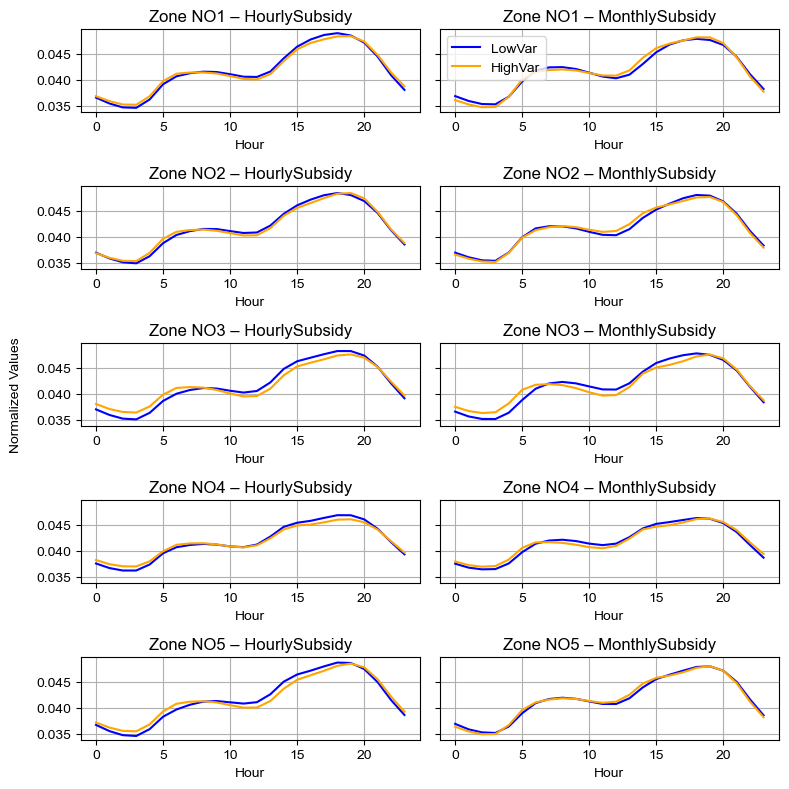

In [10]:

# Get unique periods
a = np.unique(df.Period)
# Create a list of dataframes, one for each period
dfs = [df.loc[df.Period == period] for period in a]
# Labels are just the unique periods
labels = list(a)
comparison_all, flatness_all, tables_all = analyze_multiple_periods(dfs, labels,Top=Top)


### 7. Additional SEB Calculation (Baseline: Monthly Subsidy Period)
This Figure is generated  using the **Monthly Subsidy** period as a reference to determine the Saved Energy Bill (SME)

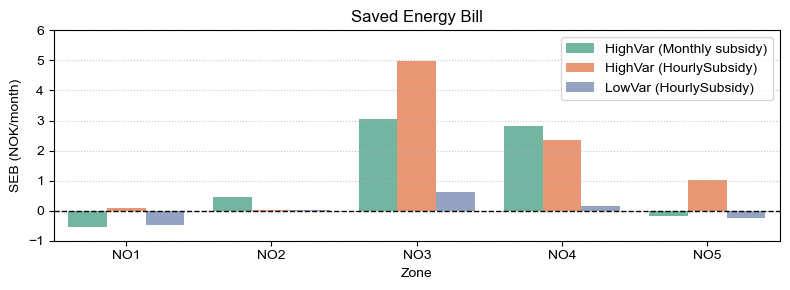

In [11]:
results = []

for zone, zone_group in comparison_all.groupby("Zone"):
    # Baseline: MonthlySubsidy
    days=30
    baseline_group = zone_group[zone_group["Period"] == "MonthlySubsidy"]
    hours = baseline_group["hour"].values
    
    # --- Curve 1: Baseline Monthly profile × Normalized Monthly price ---
    baseline= baseline_group["BaselineFraction"].values

    
    # --- Curve 2: HighVar Monthly profile × Monthly price ---
    diff_monthly = (baseline- baseline_group["HighVarFraction"].values) * baseline_group["MeanHourlyPrice_HighVar"].values/baseline_group["MeanHourlyPrice_HighVar"].values.sum()*24*30*CAve.values
    
    
    # --- Curve 3: HighVar Hourly profile × Hourly price ---
    hourly_group = zone_group[zone_group["Period"] == "HourlySubsidy"]

    
    diff_hourly_profile = (baseline-hourly_group["HighVarFraction"].values ) * hourly_group["MeanHourlyPrice_HighVar"].values/hourly_group["MeanHourlyPrice_HighVar"].values.sum()*24*30*CAve.values
    
    # --- Curve 4: Baseline Hourly profile × Hourly price ---
    diff_hourly_base = (baseline-hourly_group["BaselineFraction"].values) * hourly_group["MeanHourlyPrice_Baseline"].values/hourly_group["MeanHourlyPrice_Baseline"].values.sum()*24*30*CAve.values

    
    
    results.append({
        "Zone": zone,
        "HighVar (Monthly subsidy)": diff_monthly.sum(),
        "HighVar (HourlySubsidy)": diff_hourly_profile.sum(),
        "LowVar (HourlySubsidy)" :diff_hourly_base.sum(),
    })

# Results summary
results_df = pd.DataFrame(results)

plt.figure(figsize=(8,3))

# Melt DataFrame to long format
df_melted = results_df.melt(id_vars="Zone", 
                             value_vars=["HighVar (Monthly subsidy)", "HighVar (HourlySubsidy)", "LowVar (HourlySubsidy)"],
                             var_name="Metric", value_name="Value")

# Grouped bar plot
sns.barplot(data=df_melted, x="Zone", y="Value", hue="Metric", palette='Set2')

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('Saved Energy Bill')
plt.ylim([-1,6])
plt.ylabel(r'SEB (NOK/month)')
plt.xlabel('Zone')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("SEB.png", dpi=300)  # save as PNG

plt.show()


In [12]:
Top=5
def daily_metrics_analysis(Ori,Top):
    daily_results = []
    
    for (date, zone, period), day_df in Ori.groupby(['date', 'Zone','Period']):
        
        day_df = day_df.sort_values('hour').reset_index(drop=True)
        
        prices = day_df['Price'].values
        period_level = day_df['Period'].iloc[0]
        consumption_fractions = day_df['HourlyFraction'].values
        var_level = day_df['PriceVariationLevel'].iloc[0]
        
        if len(prices) != 24 or len(consumption_fractions) != 24:
            continue
        
        # ====== 1. PEAK-TO-DEFICIT (P/D) ======
        pd_metric = np.max(consumption_fractions) - np.min(consumption_fractions)
        
        # ====== 2. TOP5 METRIC ======

        high_idx = np.argsort(prices)[-Top:]
        high_Uidx = np.argsort(consumption_fractions)[-Top:]
        
        
        high_Psum = np.sum(consumption_fractions[high_idx])*100
        high_Csum = np.sum(consumption_fractions[high_Uidx])*100
        
        
        daily_results.append({
            'date': date,
            'Zone': zone,
            'Period': period_level,
            'PriceVariationLevel': var_level,
            'PD': pd_metric,
            'Top5P': high_Psum,
            'Top5C': high_Csum
        })
    
    return pd.DataFrame(daily_results)

### 8. Distribution of P/T distance and Consumption share in top-5 price hours
The plots in the paper compute the flatness of averaged profiles. This plot shows the distribution of falteness metric computed daily. 

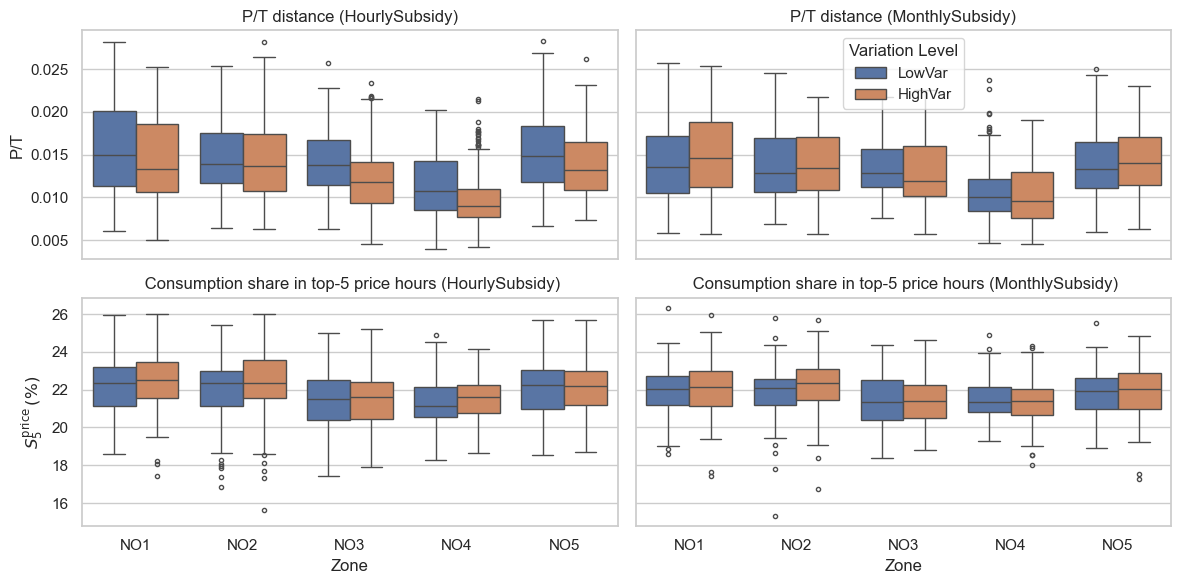

In [13]:
daily_results=daily_metrics_analysis(tables_all,Top)

# Filter to keep only Low and VeryHigh
df_filtered = daily_results[daily_results['PriceVariationLevel'].isin(['Low', 'VeryHigh'])].copy()

# Rename the levels
df_filtered['PriceVariationLevel'] = df_filtered['PriceVariationLevel'].map({
    'Low': 'LowVar',
    'VeryHigh': 'HighVar'
})

# Reset index
df_filtered = df_filtered.reset_index(drop=True)

# Setup for visualization
zone_order = ["NO1", "NO2", "NO3", "NO4", "NO5"]
var_order = ["LowVar", "HighVar"]
metrics = ["PD", "Top5"]
periods = df_filtered["Period"].unique()

import matplotlib.pyplot as plt
import seaborn as sns

# Enforce consistent ordering (important)
zone_order = sorted(df_filtered['Zone'].unique())
var_order = ['LowVar', 'HighVar']
period_order = ['HourlySubsidy','MonthlySubsidy']  # adjust if needed

sns.set(style="whitegrid")

# 2 rows (PD, Top5) x 2 columns (Periods)
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey='row')

for j, period in enumerate(period_order):
    df_p = df_filtered[df_filtered['Period'] == period]


    ax_PT = axes[0, j]
    sns.boxplot(
        data=df_p,
        x='Zone',
        y='PD',
        hue='PriceVariationLevel',
        order=zone_order,
        hue_order=var_order,
        flierprops=dict(marker='o', markersize=3),
        ax=ax_PT
    )
    ax_PT.set_title(f'P/T distance ({period})')
    ax_PT.set_xlabel('Zone')
    ax_PT.set_ylabel('P/T')



    ax_t5 = axes[1, j]
    sns.boxplot(
        data=df_p,
        x='Zone',
        y='Top5P',
        hue='PriceVariationLevel',
        order=zone_order,
        hue_order=var_order,
        flierprops=dict(marker='o', markersize=3),
        ax=ax_t5
    )
    ax_t5.set_title(f' Consumption share in top-5 price hours ({period})')
    ax_t5.set_xlabel('Zone')
    ax_t5.set_ylabel(r'$ S^{\text{price}}_5 \, (\%)$')

    # 
        # ---- Bottom row: Top5 ----
    #ax_t5C = axes[2, j]
    #sns.boxplot(
        #data=df_p,
        #x='Zone',
        #y='Top5C',
        #hue='PriceVariationLevel',
        #order=zone_order,
       # hue_order=var_order,
        #flierprops=dict(marker='o', markersize=3),
        #ax=ax_t5C)
    #ax_t5C.set_title(f'Top 5 Demand Hours ({period})')
    #ax_t5C.set_xlabel('Zone')
    #ax_t5C.set_ylabel('')
    

# ---- Clean up legends (avoid duplicates) ----
# Keep only one legend (top-right plot)
handles, labels = axes[0, 1].get_legend_handles_labels()

for ax in axes.flat:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    
#fig.supylabel('Percent of daily consumption (%)')
fig.subplots_adjust(left=0.08)
axes[0, 1].legend(handles, labels, title='Variation Level')
fig.savefig("DailyMetrics", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


In [14]:
mean_diff = (
    df_filtered
    .groupby(['Period', 'Zone', 'PriceVariationLevel'])[['PD', 'Top5P']]
    .mean()
    .reset_index()
)

mean_diff = mean_diff.pivot_table(
    index=['Period', 'Zone'],
    columns='PriceVariationLevel',
    values=['PD', 'Top5P']
)

# compute differences only
mean_diff[('PD', 'Diff')] = (
    (mean_diff[('PD', 'LowVar')] - mean_diff[('PD', 'HighVar')])/mean_diff[('PD', 'LowVar')] *100
)

mean_diff[('Top5P', 'Diff')] = (
    mean_diff[('Top5P', 'LowVar')] - mean_diff[('Top5P', 'HighVar')]
)

# keep only Diff columns + index
mean_diff = mean_diff[[('PD', 'Diff'), ('Top5P', 'Diff')]]

# flatten structure and bring Period/Zone back
mean_diff = mean_diff.reset_index()

# optional: flatten column names
mean_diff.columns = ['Period', 'Zone', 'pd_Diff', 'Top5P_Diff']

flatness_all_fil= flatness_all[['Period', 'Zone', 'SEB_Diff']].drop_duplicates()

mean_diff = mean_diff.merge(
    flatness_all_fil,
    on=['Period', 'Zone'],
    how='left'
)

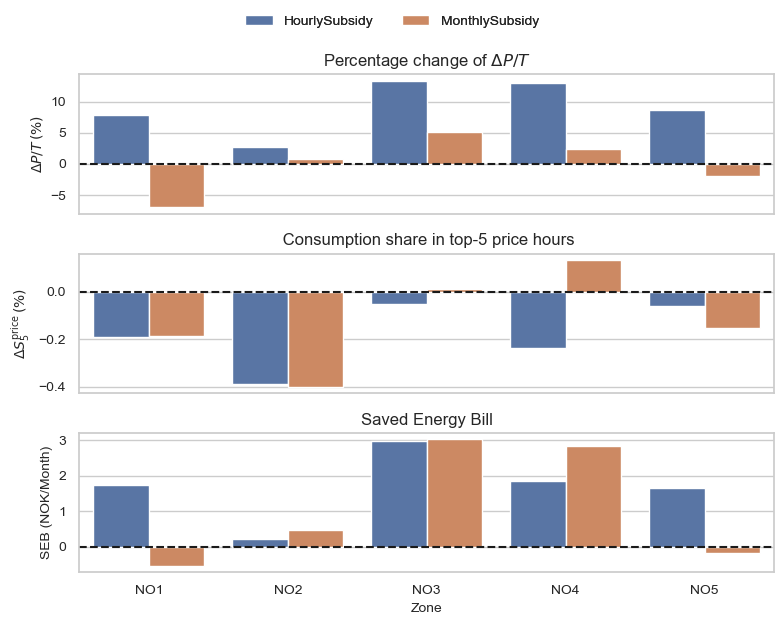

In [15]:
visualize_flatness(mean_diff)

### 9. Methodology: Constructing a Fair Comparison (Stratified Volatility)

To measure how households respond to price signals, we compare days with **Low Price Volatility** (our Baseline) against days with **Very High Price Volatility**. However, a simple ranking of price differences would be biased by factors like winter heating demand or regional market structures.

To ensure the results are scientifically valid, we implement a **Stratified Quartile Approach**. This ensures that the "Quartile" divisions you see in the following charts are consistent and rigorously balanced.

#### The Logic of Stratification
Every day in our dataset is assigned a volatility rank from Low to Very High. To ensure a "like-for-like" comparison, this ranking is performed independently within specific "buckets":

* **By Bidding Zone (NO1–NO5):** We account for the structural differences in regional power markets (e.g., comparing Oslo to Tromsø).
* **By Regulatory Period:** We ensure that transitions in government subsidy models are analyzed within their own policy context.
* **By Seasonality:** A "High Volatility" day in Summer is defined relative to other Summer days. This prevents extreme Winter price spreads from dominating the entire dataset.
* **By Day Type (Weekday vs. Weekend):** We separate these to account for the natural differences in household routines and industrial base loads.

#### Validating the Distribution (The Visuals Below)
The following visualizations serve as a "health check" for this stratification process:
* **Price Levels & Variation:** The box plots and heatmaps confirm that days labeled "Very High" actually represent significantly different price environments than "Low" days, even after controlling for the zone and period.
* **Temporal Consistency:** The bar charts demonstrate how many "Low" vs. "Very High" days were identified during Weekends and across different Seasons (Winter vs. Summer).

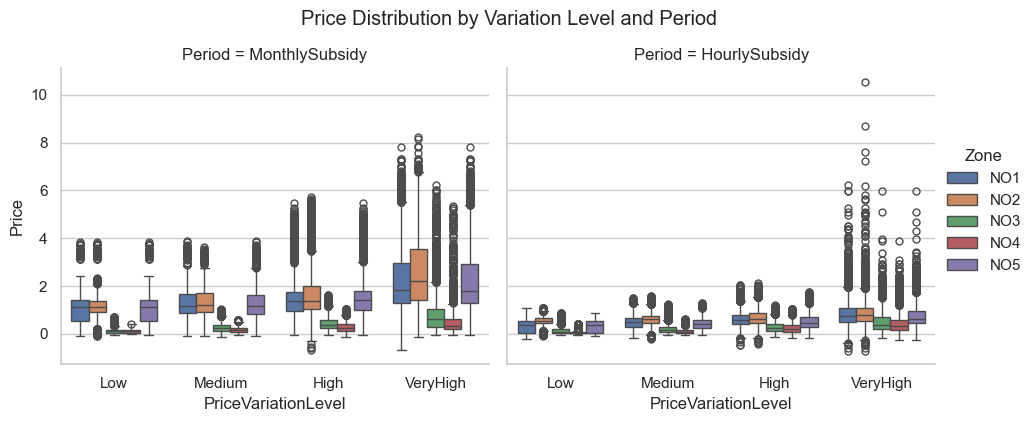

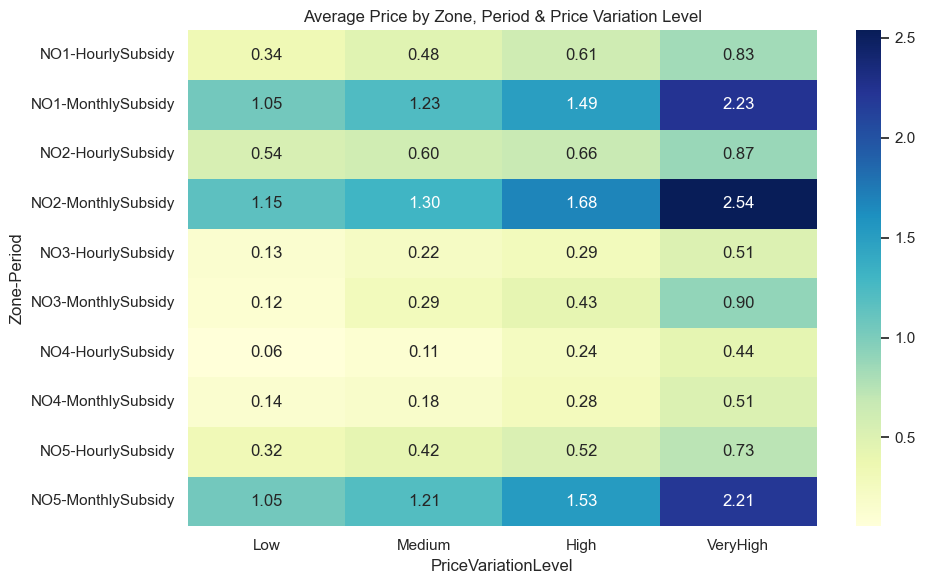

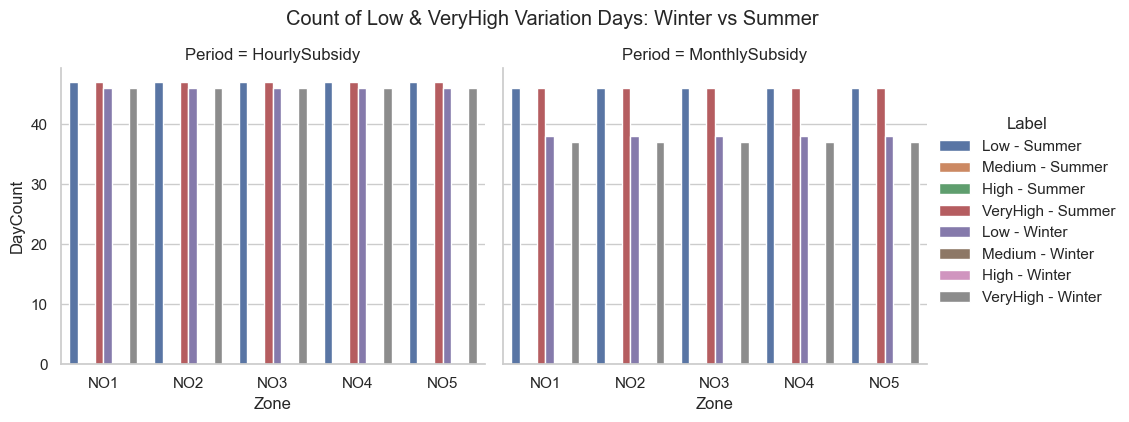

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup and Feature Engineering
# ---------------------------
A = df.copy()
A['date'] = A.index.normalize()
A['hour'] = A.index.hour
A['month'] = A.index.month

# Efficiently calculate hourly fraction using vectorized operations
A['DailyTotal'] = A.groupby(['Zone', 'date'])['Consumption'].transform('sum')
A['HourlyFraction'] = A['Consumption'] / A['DailyTotal']

# 2. Daily Aggregation & Categorization
# ---------------------------
# Vectorized season mapping
season_map = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11]
}
month_to_season = {m: s for s, months in season_map.items() for m in months}

# Aggregate daily stats
A_daily = A.groupby(['Zone', 'Period', 'date']).agg(
    Price_Max=('Price', 'max'),
    Price_Min=('Price', 'min')
).reset_index()

A_daily['PriceDiff'] = A_daily['Price_Max'] - A_daily['Price_Min']
A_daily['Season'] = A_daily['date'].dt.month.map(month_to_season)
A_daily['is_weekend'] = A_daily['date'].dt.dayofweek >= 5

# 3. Stratified Quartiles
# ---------------------------
# Assign quartiles stratified by Zone, Period, Season, and Weekend status
A_daily['PriceVariationLevel'] = (
    A_daily.groupby(['Zone', 'Period', 'Season', 'is_weekend'])['PriceDiff']
    .transform(lambda x: pd.qcut(x, q=4, labels=['Low', 'Medium', 'High', 'VeryHigh']) 
               if len(x.unique()) >= 4 else 'Medium') 
)

# Merge back into original hourly data
A = A.merge(
    A_daily[['Zone', 'Period', 'date', 'PriceVariationLevel', 'Season', 'is_weekend']], 
    on=['Zone', 'Period', 'date'], 
    how='left'
)

# 4. Visualizations
# ---------------------------
sns.set_theme(style="whitegrid")

# Plot 1: Price Distributions
g1 = sns.catplot(
    data=A, x="PriceVariationLevel", y="Price", hue="Zone",
    kind="box", col="Period", col_wrap=2, height=4, aspect=1.2
)
g1.fig.suptitle("Price Distribution by Variation Level and Period", y=1.05)

# Plot 2: Heatmap of Average Prices
pivot_table = A.pivot_table(
    index=['Zone', 'Period'], 
    columns='PriceVariationLevel', 
    values='Price', 
    aggfunc='mean'
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Average Price by Zone, Period & Price Variation Level")
plt.tight_layout()

# Plot 3: Seasonality & Weekend Validation
# Filtering for focal points (Low and VeryHigh) in specific seasons
focus_mask = (A['PriceVariationLevel'].isin(['Low', 'VeryHigh'])) & \
             (A['Season'].isin(['Winter', 'Summer']))

# Count unique days efficiently
season_counts = (
    A[focus_mask].groupby(['Zone', 'Period', 'Season', 'PriceVariationLevel'])['date']
    .nunique()
    .reset_index(name='DayCount')
)

# FIXED: Convert Categorical to String to avoid TypeError during concatenation
season_counts['Label'] = (
    season_counts['PriceVariationLevel'].astype(str) + 
    " - " + 
    season_counts['Season'].astype(str)
)

g2 = sns.catplot(
    data=season_counts, x='Zone', y='DayCount', hue='Label',
    col='Period', kind='bar', height=4, aspect=1.2
)
g2.fig.suptitle("Count of Low & VeryHigh Variation Days: Winter vs Summer", y=1.05)

plt.show()

### 10. Plot Used to Explain the Method of Calculating SEB (Used in Method Section) 


In [17]:


f_df = comparison_all[
    (comparison_all['Period'] == "HourlySubsidy") &
    (comparison_all['Zone'] == "NO5")
]


T_df=tables_all[
    (tables_all['Period'] == "HourlySubsidy") &
    (tables_all['Zone'] == "NO5")
]

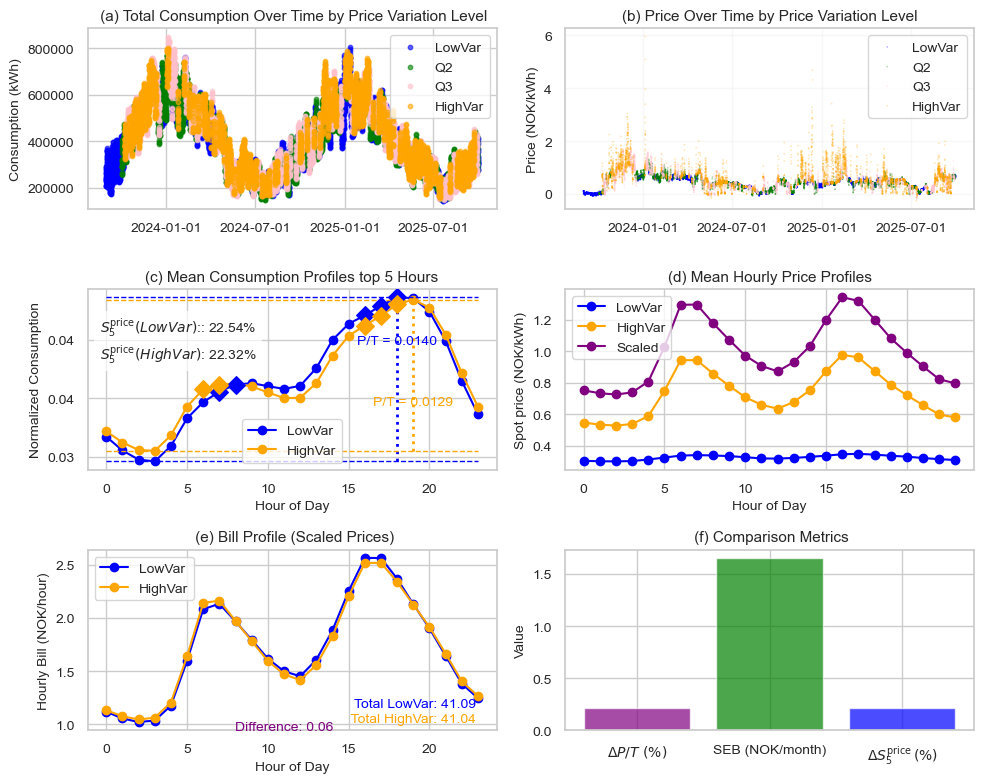

In [18]:
def plot_pd_subplot(f_df, T_df):
    """
    Plot:
    - Row 1: Continuous Consumption and Price colored by PriceVariationLevel
    - Row 2: Baseline & HighVar Fraction with P/D
    - Row 3: Hourly Bills using HighVar prices, PD change % and SEB
    """

    sns.set(style="whitegrid")
    plt.rcParams.update({
    'axes.labelsize': 10,       # Axis labels
    'axes.titlesize': 11,       # Titles
    'xtick.labelsize': 10,      # X tick labels
    'ytick.labelsize': 10,      # Y tick labels
    'legend.fontsize': 10,      # Legend text
    'font.family': 'Arial'      # Font family
})
    
    fig, axes = plt.subplots(3, 2, figsize=(10,8), gridspec_kw={'height_ratios': [1, 1, 1]})



    # Define palette with renamed levels
    palette = {
        "Low": "blue",        
        "Medium": "green",
        "High": "pink",     
        "VeryHigh": "orange"
    }

    # Name mapping for legend display
    name_mapping = {
        "Low": "LowVar",
        "Medium": "Q2",
        "High": "Q3",
        "VeryHigh": "HighVar"
    }

    # =========================
    # ROW 1, COL 1: Consumption time series colored by PriceVariationLevel
    # =========================
    ax0 = axes[0, 0]
    for level, color in palette.items():
        subset = T_df[T_df['PriceVariationLevel'] == level]
        ax0.scatter(subset['date'], subset['Consumption'], color=color, label=name_mapping.get(level, level), s=10,alpha=0.6)

    ax0.set_title(" (a) Total Consumption Over Time by Price Variation Level")
    ax0.set_ylabel("Consumption (kWh)")
    ax0.grid(True)

    ax0.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))
    ax0.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax0.legend(title=None)

    # =========================
    # ROW 1, COL 2: Price time series colored by PriceVariationLevel
    # =========================
    ax1 = axes[0, 1]
    for level, color in palette.items():
        subset = T_df[T_df['PriceVariationLevel'] == level]
        ax1.scatter(
        subset['date'],
        subset['Price'],
        color=color,
        label=name_mapping.get(level, level),
        s=6,
        alpha=0.3,
        marker='.',
        edgecolors='none'
    )
    
    ax1.set_title("(b) Price Over Time by Price Variation Level")
    ax1.set_ylabel("Price (NOK/kWh)")
    ax1.grid(True,alpha=0.15)

    ax1.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax1.legend(title=None)

###################

    # =========================
    # ROW 2, COL 1: Baseline & HighVar Fraction with P/D
    # =========================
    ax2 = axes[1, 0]
    Top=5
    
    baseline_max = f_df['BaselineFraction'].max()
    baseline_min = f_df['BaselineFraction'].min()
    highvar_max = f_df['HighVarFraction'].max()
    highvar_min = f_df['HighVarFraction'].min()
    
    top5_baseline_idx = np.argsort(f_df['BaselineFraction'].values)[-Top:]
    top5_highvar_idx  = np.argsort(f_df['HighVarFraction'].values)[-Top:]
    top5_price_baseline_idx = np.argsort(f_df['MeanHourlyPrice_Baseline'].values)[-Top:]
    top5_price_highvar_idx  = np.argsort(f_df['MeanHourlyPrice_HighVar'].values)[-Top:]

    pd_baseline = baseline_max - baseline_min
    pd_highvar = highvar_max - highvar_min

# --- Sum consumption corresponding Top 5 Price 
    Top5C_at_price_baseline = np.sum(
        f_df['BaselineFraction'].values[top5_price_baseline_idx]) * 100
    
    Top5C_at_price_highvar = np.sum(
        f_df['HighVarFraction'].values[top5_price_highvar_idx] ) * 100
    
    # --- Sum consumption corresponding Top 5 consumption
    
    Top5C_baseline =  np.sum(f_df['BaselineFraction'].values[top5_baseline_idx])*100
    Top5C_highvar = np.sum(f_df['HighVarFraction'].values[top5_baseline_idx])*100


    # Original lines
    ax2.plot(f_df['hour'], f_df['BaselineFraction'],
             label="LowVar", color="blue", marker="o")
    
    ax2.plot(f_df['hour'], f_df['HighVarFraction'],
             label="HighVar", color="orange", marker="o")
    
    # Overlay TOP 5 points with diamond markers
    ax2.scatter(f_df['hour'].iloc[top5_price_baseline_idx],
                f_df['BaselineFraction'].iloc[top5_price_baseline_idx],
                color="blue", marker="D", s=80, zorder=3, label="_nolegend_")
    
    ax2.scatter(f_df['hour'].iloc[top5_price_highvar_idx],
                f_df['HighVarFraction'].iloc[top5_price_highvar_idx],
                color="orange", marker="D", s=80, zorder=3, label="_nolegend_")

    ax2.hlines(y=baseline_max, xmin=0, xmax=23, colors="blue", linestyles="dashed", linewidth=1)
    ax2.hlines(y=baseline_min, xmin=0, xmax=23, colors="blue", linestyles="dashed", linewidth=1)
    ax2.vlines(x=f_df['hour'][f_df['BaselineFraction'].idxmax()],
               ymin=baseline_min, ymax=baseline_max,
               colors="blue", linestyles="dotted", linewidth=2)
    
    ax2.text(f_df['hour'][f_df['BaselineFraction'].idxmax()], baseline_max - 0.004,
             f"P/T = {pd_baseline:.4f}", color="blue", fontsize=10, ha="center")

    ax2.hlines(y=highvar_max, xmin=0, xmax=23, colors="orange", linestyles="dashed", linewidth=1)
    ax2.hlines(y=highvar_min, xmin=0, xmax=23, colors="orange", linestyles="dashed", linewidth=1)
    ax2.vlines(x=f_df['hour'][f_df['HighVarFraction'].idxmax()],
               ymin=highvar_min, ymax=highvar_max,
               colors="orange", linestyles="dotted", linewidth=2)
    
    ax2.text(f_df['hour'][f_df['HighVarFraction'].idxmax()], highvar_max - 0.009,
             f"P/T = {pd_highvar:.4f}", color="orange", fontsize=10, ha="center")
    


    ax2.set_title("(c) Mean Consumption Profiles top 5 Hours")
    ax2.set_xlabel("Hour of Day")
    ax2.set_ylabel("Normalized Consumption")

    ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))  # ← Two decimal places


    ax2.text(
    0.03, 0.85,
    f"$S^{{\\text{{price}}}}_5(LowVar)$:: {Top5C_at_price_baseline:.2f}%\n"
    f"$S^{{\\text{{price}}}}_5(HighVar)$: {Top5C_at_price_highvar:.2f}%",
    transform=ax2.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)


   # Consumption share in top-5 price hours
    
    ax2.legend(loc='lower center')

    # =========================
    # ROW 2, COL 2: Mean Hourly Prices
    # =========================
    ax3 = axes[1, 1]
    ax3.plot(f_df['hour'], f_df['MeanHourlyPrice_Baseline'], label="LowVar", color="blue", marker="o")
    ax3.plot(f_df['hour'], f_df['MeanHourlyPrice_HighVar'], label="HighVar", color="orange", marker="o")
    ax3.plot(f_df['hour'], f_df['MeanHourlyPrice_HighVar']/f_df['MeanHourlyPrice_HighVar'].sum()*24, label="Scaled", color="purple", marker="o")

    #ax3.scatter(f_df['hour'].iloc[top5_price_baseline_idx],f_df['MeanHourlyPrice_Baseline'].iloc[top5_price_baseline_idx],color="blue", marker="D", s=80, zorder=3, label="-")
    
    #ax3.scatter(f_df['hour'].iloc[top5_price_highvar_idx],f_df['MeanHourlyPrice_HighVar'].iloc[top5_price_highvar_idx],color="orange", marker="D", s=80, zorder=3, label="-") 

    ax3.set_title("(d) Mean Hourly Price Profiles")
    ax3.set_xlabel("Hour of Day")
    ax3.set_ylabel("Spot price (NOK/kWh)")
    ax3.legend()


    # =========================
    # ROW 3, COL 1: Hourly Bills using HighVar prices
    # =========================
    ax4 = axes[2, 0]
    price_scale = f_df['MeanHourlyPrice_HighVar'].sum()
    baseline_bill = f_df['BaselineFraction'] * f_df['MeanHourlyPrice_HighVar'] / price_scale * 24*CAve.values
    highvar_bill = f_df['HighVarFraction'] * f_df['MeanHourlyPrice_HighVar'] / price_scale * 24*CAve.values

    ax4.plot(f_df['hour'], baseline_bill, label="LowVar", color="blue", marker="o")
    ax4.plot(f_df['hour'], highvar_bill, label="HighVar", color="orange", marker="o")

    baseline_total = baseline_bill.sum()
    highvar_total = highvar_bill.sum()

    ax4.text(0.95, 0.18, f"Total LowVar: {baseline_total:.2f}", transform=ax4.transAxes,
             fontsize=10, color="blue", ha="right", va="top")
    ax4.text(0.95, 0.1, f" Total HighVar: {highvar_total:.2f}", transform=ax4.transAxes,
             fontsize=10, color="orange", ha="right", va="top")
    ax4.text(0.6, 0.05, f"Difference: {baseline_total-highvar_total:.2f}", transform=ax4.transAxes,
             fontsize=10, color="purple", ha="right", va="top")

    ax4.set_title(" (e) Bill Profile (Scaled Prices)")
    ax4.set_xlabel("Hour of Day")
    ax4.set_ylabel("Hourly Bill (NOK/hour)")
    ax4.legend(loc="upper left")  # ← Legend top left

    # =========================
    # ROW 3, COL 2: Metrics and SEB
    # =========================
    ax5 = axes[2, 1]
    pd_change_percent=(pd_baseline-pd_highvar)/pd_baseline*100
    
    Top5C_change_percent = (Top5C_baseline - Top5C_highvar) 
    Top5P_change_percent = (Top5C_at_price_baseline - Top5C_at_price_highvar)
    seb = (baseline_bill - highvar_bill).sum() * 30

    ax5.bar(["P/T Change (%)"], [Top5C_change_percent], color="purple", alpha=0.7)
    ax5.bar(["SEB"], [seb], color="green", alpha=0.7)
    ax5.bar(["CV Change"], [Top5P_change_percent], color="blue", alpha=0.7)

    ax5.set_title(" (f) Comparison Metrics")
    ax5.set_ylabel("Value")
    ax5.set_xticks([0, 1, 2])
    ax5.set_xticklabels([
    r'$\Delta P/T\ (\%)$',
    'SEB (NOK/month)',
    r'$ \Delta S^{\text{price}}_5 \, (\%)$'])

    plt.tight_layout()
    plt.savefig("Method.png", dpi=300, bbox_inches="tight")

    plt.show()
plot_pd_subplot(f_df, T_df)


### 11. Plot of Norway price adoption rate


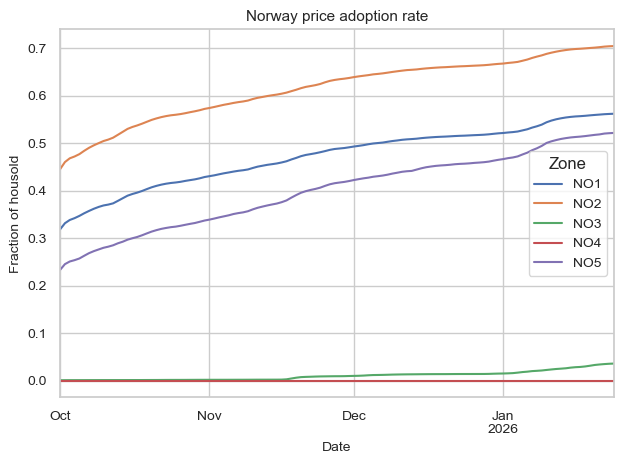

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Read and filter
A = (
    pd.read_csv("NorgeCount.csv", sep=";")
      .query("FORBRUKSGRUPPE == 'Husholdning'")
      .assign(Fraction=lambda df: df.ANTALL_NORGESPRIS / df.ANTALL,
              DATO=lambda df: pd.to_datetime(df.DATO))
      .set_index('DATO')
)

# Plot
plt.figure()
for zone, g in A.groupby('PRISOMRÅDE'):
    g['Fraction'].plot(label=zone)

plt.xlabel('Date')
plt.ylabel('Fraction of housold')
plt.title('Norway price adoption rate')
plt.legend(title='Zone')
plt.tight_layout()
fig.savefig("NorwayAdoptation.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:

df_Norge = df_base[df_base.index.month.isin([10,11,12,1,2])]
df_Norge = df_Norge.copy()  # make a safe copy
df_Norge.loc[:, 'date'] = df_Norge.index.date
df_Norge.loc[:, 'year'] = df_Norge.index.year
df_Norge.loc[:, 'month'] = df_Norge.index.month
df_Norge.loc[:, 'hour'] = df_Norge.index.hour


### 12.  Plot for Normalized consumption and P/T change 
This graphic compares the normalized consumption for three subsidy periods (only winter months). This is not included in the paper.

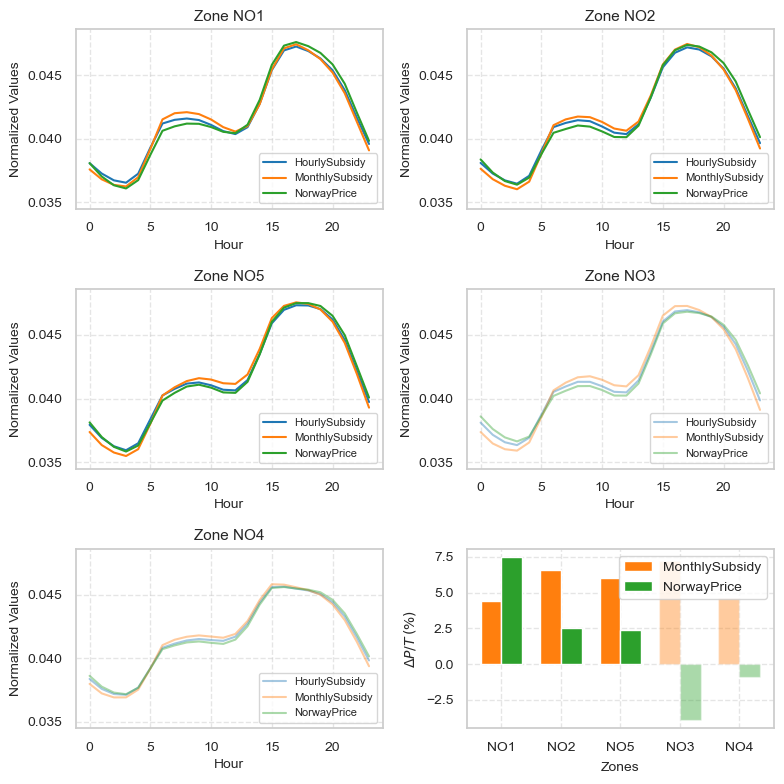

In [21]:
# --- Compute HourlyFraction per day, per period separately ---
Fractions_list = []

for period in df_Norge['Period'] .unique():
    df_period = df_Norge[df_Norge['Period'] == period].copy()

    # Daily total only for this period
    df_period['DailyTotal'] = df_period.groupby(['Zone','date'])['Consumption_per_household'].transform('sum')
    df_period['HourlyFraction'] = df_period['Consumption_per_household'] / df_period['DailyTotal']

    Fractions_list.append(df_period)

# Combine all periods back
Fractions = pd.concat(Fractions_list)

# --- Compute mean hourly fraction across days for each Zone × Period × hour ---
Fractions_mean = (
    Fractions.groupby(['Zone','Period','hour'])[['HourlyFraction','Price']]
             .mean()
             .reset_index()
)

# --- Verify sum = 1 ---
sum_check = Fractions_mean.groupby(['Zone','Period'])['HourlyFraction'].sum().reset_index(name='SumCheck')
#print(sum_check)




# --- Configuration ---
important_zones = ['NO1','NO2','NO5']
other_zones = ['NO3','NO4']
all_zones = important_zones + other_zones
periods = sorted(Fractions_mean['Period'].unique())
baseline_period = 'HourlySubsidy'
plot_periods = [p for p in periods if p != baseline_period]  # periods other than baseline

# Colors for periods (same for line plots and bars)
period_colors = {
    periods[0]: 'tab:blue',
    periods[1]: 'tab:orange',
    periods[2]: 'tab:green'
}

# --- Figure setup ---
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

# --- Determine common Y-axis limits for subplots 1–5 ---
ymin = Fractions_mean['HourlyFraction'].min()
ymax = Fractions_mean['HourlyFraction'].max()
y_padding = 0.001
ymin -= y_padding
ymax += y_padding

# --- Subplots 1 to 5: Line plots ---
for idx, zone in enumerate(all_zones[:5]):
    ax = axes[idx]
    zone_data = Fractions_mean[Fractions_mean['Zone'] == zone]
    
    for period in periods:
        p_data = zone_data[zone_data['Period'] == period]
        alpha_val = 1.0 if zone in important_zones else 0.4
        ax.plot(p_data['hour'], p_data['HourlyFraction'], label=period, 
                alpha=alpha_val, color=period_colors[period])
    
    ax.set_title(f"Zone {zone}")
    
    # X-axis ticks
    xticks = [0, 5, 10, 15, 20]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    
    # Force same Y-axis across all 5 subplots
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.linspace(ymin, ymax, 3))  # 3 evenly spaced ticks
    ax.set_ylim(ymin, ymax)
    ax.set_yticks([0.035,0.040,0.045])  # 3 evenly spaced ticks
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))  # show 3 digits

    
    ax.set_xlabel('Hour')
    ax.set_ylabel('Normalized Values')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='', fontsize=8, loc='lower right')

# --- 6th subplot: Bar plot of % change vs HourlySubsidy ---
ax = axes[5]

# Prepare percentage change data
pct_changes = []
for zone in all_zones:
    zone_data = Fractions_mean[Fractions_mean['Zone'] == zone]
    
    # PD baseline
    PD_base = zone_data[zone_data['Period'] == baseline_period]['HourlyFraction'].max() - \
              zone_data[zone_data['Period'] == baseline_period]['HourlyFraction'].min()

    # PD % change for other periods
    pct_list = []
    for period in plot_periods:
        PD = zone_data[zone_data['Period'] == period]['HourlyFraction'].max() - \
             zone_data[zone_data['Period'] == period]['HourlyFraction'].min()
        pct = 100 * (PD - PD_base) / PD_base if PD_base != 0 else 0
        pct_list.append(pct)
    pct_changes.append(pct_list)

pct_changes = np.array(pct_changes)  # shape: (5 zones, 2 periods)
x = np.arange(len(all_zones))
bar_width = 0.35

# Plot bars per period using same color as line plots
for i, period in enumerate(plot_periods):
    for j, zone in enumerate(all_zones):
        alpha_val = 1.0 if zone in important_zones else 0.4
        ax.bar(x[j] + i*bar_width, pct_changes[j, i], width=bar_width,
               label=period if j==0 else "", 
               alpha=alpha_val, color=period_colors[period])

# X and Y labels for 6th subplot
ax.set_xticks(x + bar_width*(len(plot_periods)-1)/2)
ax.set_xticklabels(all_zones)
ax.set_xlabel('Zones', fontsize=10, labelpad=6)
ax.set_ylabel(r'$\Delta P/T \, (\%)$', fontsize=10, labelpad=6)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='', fontsize=10, loc='upper right')
plt.tight_layout()
fig.savefig("HrCoNO.png", dpi=300)
plt.show()

### 14.  Plot of Daily Metrics 
This plot gives the distribution of metrics computed daily.

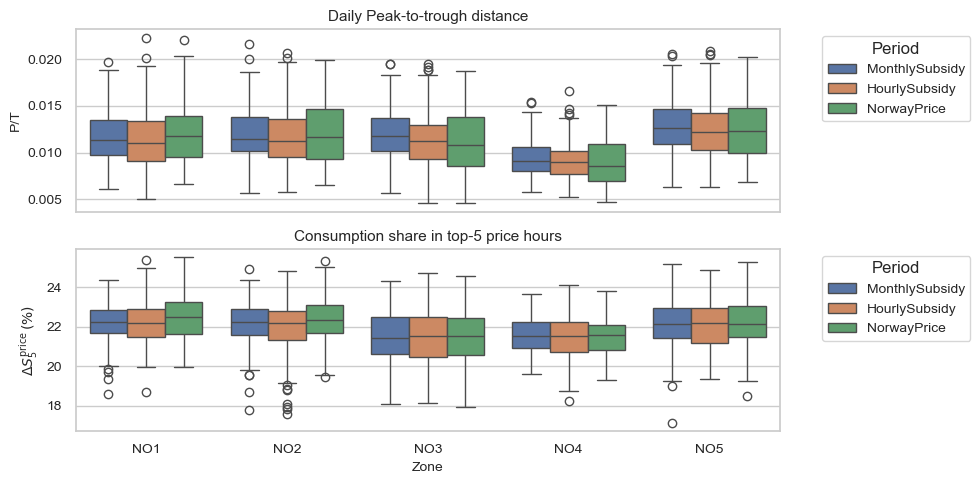

In [24]:
TopN=5
daily_results=[]
# Group by date and Zone
for (date, zone, period), day_df in df_Norge.groupby(['date', 'Zone','Period']):


    def Top5P(p, q, TopN=5):
        p = np.asarray(p)
        q = np.asarray(q)
        high_idx = np.argsort(q)[-TopN:]
        return np.sum(p[high_idx])
    
    
    # Sort by hour to ensure 24-hour order
    day_df = day_df.sort_values('hour').reset_index(drop=True)
    
    # Extract hourly series
    prices = day_df['Price'].values
    peroid_level = day_df['Period'].iloc[0]
    consumption_raw = day_df['Consumption_per_household'].values
    consumption_total=consumption_raw.sum()
    consumption_fractions = consumption_raw / consumption_total
    
    # Skip if incomplete day
    if len(prices) != 24 or len(consumption_fractions) != 24:
        continue
    
    # ====== 1. PEAK-TO-DEFICIT (P/D) ======
    pd_metric = np.max(consumption_fractions) - np.min(consumption_fractions)
    
    # ====== 2. TopN  ======
    Top5= Top5P(consumption_fractions, prices, TopN)*100
    
    
    # Append results
    daily_results.append({
        'date': date,
        'Zone': zone,
        'Period': peroid_level,
        'PD': pd_metric,
        'Top5': Top5
    })

daily_results_df = pd.DataFrame(daily_results)

zone_order = ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']

daily_results_df['Zone'] = pd.Categorical(
    daily_results_df['Zone'],
    categories=zone_order,
    ordered=True
)


import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10,5), sharex=True)

# --- Top: PD ---
sns.boxplot(
    data=daily_results_df,
    x="Zone",
    y="PD",
    hue="Period",
    ax=axes[0]
)
axes[0].set_title("Daily Peak-to-trough distance")
axes[0].legend(title="Period", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_ylabel('P/T')
# --- Bottom: Elasticity ---
sns.boxplot(
    data=daily_results_df,
    x="Zone",
    y="Top5",
    hue="Period",
    ax=axes[1]
)
axes[1].set_title("Consumption share in top-5 price hours")
axes[1].legend(title="Period", bbox_to_anchor=(1.05, 1), loc='upper left')
#axes[1].set_ylim(-1, 15)
axes[1].set_ylabel(r'$\Delta S^{\text{price}}_5 \, (\%)$')
plt.tight_layout()
fig.savefig("DailyMetricsNorway.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:

daily_results_df['Zone'] = pd.Categorical(
    daily_results_df['Zone'],
    categories=zone_order,
    ordered=True
)

daily_results_df = (
    daily_results_df
    .groupby(['Period', 'Zone'])[['PD', 'Top5']]
    .mean()
    .reset_index()
)


### Plot of Metrics (raw numbers)

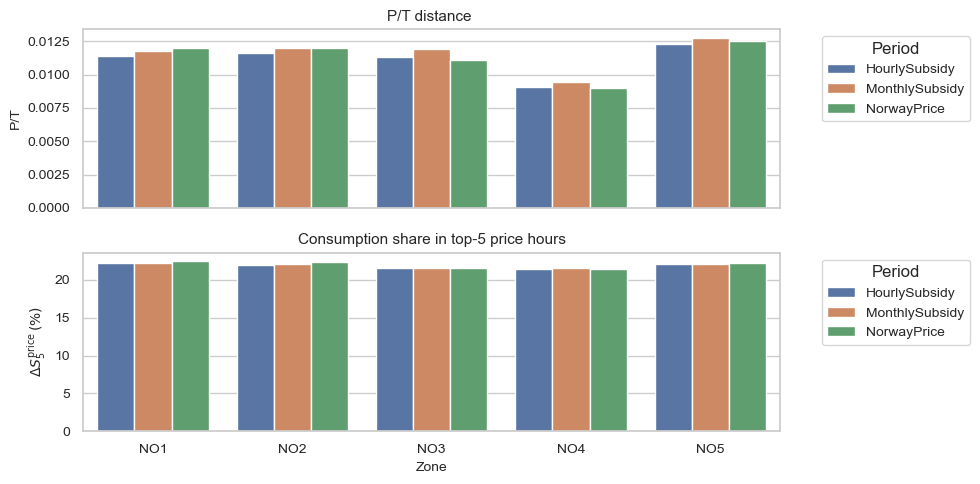

In [26]:


import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10,5), sharex=True)

# --- Top: PD ---
sns.barplot(
    data=daily_results_df,
    x="Zone",
    y="PD",
    hue="Period",
    ax=axes[0]
)
axes[0].set_title("P/T distance ")
axes[0].legend(title="Period", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_ylabel('P/T')
# --- Bottom: Elasticity ---
sns.barplot(
    data=daily_results_df,
    x="Zone",
    y="Top5",
    hue="Period",
    ax=axes[1]
)
axes[1].set_title("Consumption share in top-5 price hours")
axes[1].legend(title="Period", bbox_to_anchor=(1.05, 1), loc='upper left')
#axes[1].set_ylim(-1, 15)
axes[1].set_ylabel(r'$\Delta S^{\text{price}}_5 \, (\%)$')
plt.tight_layout()
fig.savefig("RDailyMetricsMean.png", dpi=300, bbox_inches="tight")
plt.show()


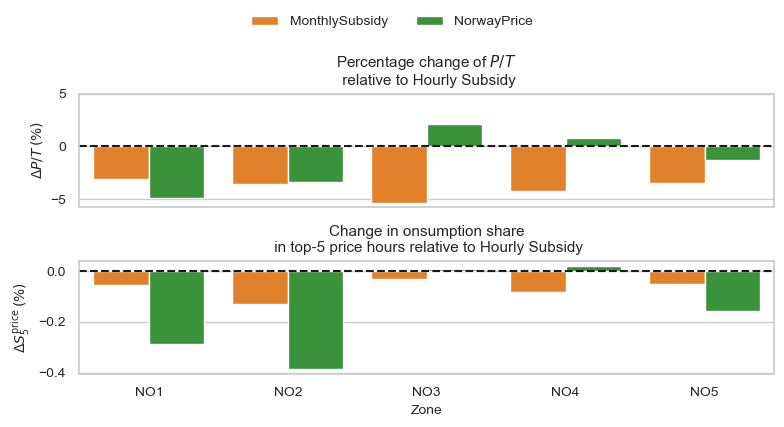

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Baseline = HourlySubsidy
baseline = (
    daily_results_df[daily_results_df["Period"] == "HourlySubsidy"]
    .set_index("Zone")
)

# Merge baseline values
df = daily_results_df.merge(
    baseline[["PD", "Top5"]],
    left_on="Zone",
    right_index=True,
    suffixes=("", "_base")
)

# Compute differences
df["PD_diff"] = (df["PD_base"]-df["PD"])/ df["PD_base"]*100
df["Top5_diff"] = df["Top5_base"]-df["Top5"] 

# Remove baseline rows
plot_df = df[df["Period"] != "HourlySubsidy"]




import matplotlib.pyplot as plt

# Define colors for the hue levels (blue and Green)
palette_colors = ["#ff7f0e", "#2ca02c"] 

# --- Grouped Bar Charts ---
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# --- Top plot: CV change ---
sns.barplot(
    data=plot_df,
    x='Zone',
    y='Top5_diff',
    hue='Period',
    palette=palette_colors,
    ax=axes[1]
)

axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_ylabel(r'$\Delta S^{\text{price}}_5 \, (\%)$')
axes[1].set_title("Change in onsumption share\n in top-5 price hours relative to Hourly Subsidy")



# --- Bottom plot: PD change ---
sns.barplot(
    data=plot_df,
    x='Zone',
    y='PD_diff',
    hue='Period',
    palette=palette_colors,
    ax=axes[0]
)

axes[0].axhline(0, color='k', linestyle='--')
axes[0].set_ylabel(r'$\Delta P/T \, (\%)$')
axes[0].set_yticks([-5, 0, 5])

title_str =  (
    r'Percentage change of $P/T$'
    '\n relative to Hourly Subsidy')

axes[0].set_title( title_str )

# --- Remove legends from axes ---
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# --- Add single shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(labels),
    frameon=False
)
plt.tight_layout()
fig.savefig("Metric2.png", dpi=300, bbox_inches="tight")
plt.show()


### 15.  Plot of absolute consumption profiles and population-weighted mean outdoor temperatures for all subsidy periods (winter Months)
This plot is included in the main paper. 

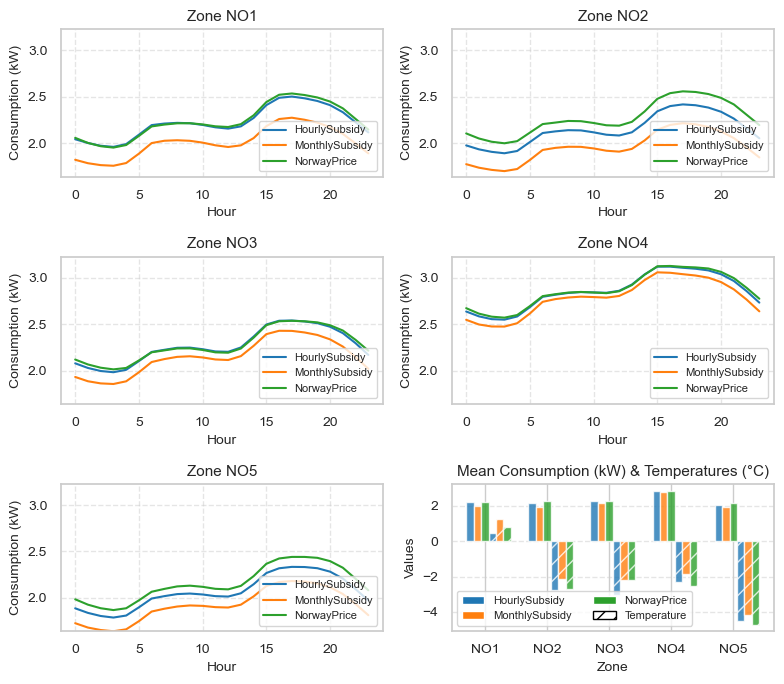

In [28]:

hourly_avg = (
    df_Norge
    .groupby(['Zone', 'Period', 'hour'])[['Consumption_per_household', 'MeanTemp']]
    .mean()
    .reset_index()
)

zones = sorted(hourly_avg['Zone'].unique())
periods = sorted(hourly_avg['Period'].unique())
hour_ticks = [0, 5, 10, 15, 20]

important_zones = zones[:5]  # for line plots
period_colors = {
    periods[0]: 'tab:blue',
    periods[1]: 'tab:orange',
    periods[2]: 'tab:green'
}

# --- 3x2 grid ---
fig, axes = plt.subplots(3, 2, figsize=(8,7))
axes = axes.flatten()

# --- Step 1: Line plots for first 5 zones ---
ymin = hourly_avg['Consumption_per_household'].min()
ymax = hourly_avg['Consumption_per_household'].max()+0.1

for idx, zone in enumerate(important_zones):
    ax = axes[idx]
    zone_data = hourly_avg[hourly_avg['Zone'] == zone]
    
    for period in periods:
        p_data = zone_data[zone_data['Period'] == period]
        ax.plot(
            p_data['hour'],
            p_data['Consumption_per_household'],
            label=period,
            color=period_colors[period]
        )

    ax.set_title(f"Zone {zone}")
    ax.set_xticks(hour_ticks)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Consumption (kW)')
    ax.set_ylim(ymin, ymax)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, loc='lower right')

ax_bar = axes[5]

# Compute means per zone per period
zone_period_means = (
    hourly_avg
    .groupby(['Zone', 'Period'])[['Consumption_per_household', 'MeanTemp']]
    .mean()
    .unstack(level=1)
)

x = np.arange(len(zones))
bar_width = 0.12  # width to fit 6 bars per zone

# Plot bars: shift positions for 6 bars per zone
for i, period in enumerate(periods):
    # Consumption bars (solid)
    ax_bar.bar(
        x - bar_width*2 + i*bar_width,
        zone_period_means['Consumption_per_household'][period].values,
        width=bar_width,
        color=period_colors[period],
        alpha=0.8
    )
    # Temperature bars (pattern)
    ax_bar.bar(
        x + bar_width + i*bar_width,
        zone_period_means['MeanTemp'][period].values,
        width=bar_width,
        color=period_colors[period],
        alpha=0.8,
        hatch='//'
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(zones)
ax_bar.set_xlabel('Zone')
ax_bar.set_ylabel('Values')
ax_bar.set_title('Mean Consumption (kW) & Temperatures (°C)')
ax_bar.grid(axis='y', linestyle='--', alpha=0.5)

# --- Legend: two columns ---
from matplotlib.patches import Patch

# Period colors for legend
period_legend = [Patch(facecolor=period_colors[period], label=period) for period in periods]
# Pattern legend for consumption vs temperature
pattern_legend = [
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Temperature')
]

# Combine legends and make 2 columns
ax_bar.legend(handles=period_legend + pattern_legend, fontsize=8, loc='lower left', ncol=2)
plt.tight_layout()
fig.savefig("AbsoluteConsumption.png", dpi=300)

plt.show()


## Econometric Analysis
We construct a sequence of regression models with the explicit purpose of separating structural, physically driven determinants of electricity consumption from potential policy-induced changes. The goal is to build an econometric baseline model that captures how consumption normally responds to temperature, time patterns, and regional differences, so that any remaining variation can more credibly be attributed to policy effects.

We begin by preparing the dataset and constructing variables that reflect known physical drivers of electricity demand. Temperature is included not only linearly but also in squared and cubic form to capture nonlinear heating effects. Calendar structure is represented through weekday indicators and a weekend dummy, while hour-of-day fixed effects capture intraday load cycles. Zone indicators account for persistent regional differences in consumption levels. I also create a log-transformed version of consumption to allow for multiplicative specifications.

The models were then defined progressively.

The comparison table below shows how the inclusion of additional physical determinants improved model fit. 
The final model is selected based on this table.


In [29]:

df = df_Norge.dropna().copy()  # Replace with your actual dataframe

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5

# Add squared and cubic temperature
df['MeanTemp_sq'] = df['MeanTemp'] ** 2
df['MeanTemp_cu'] = df['MeanTemp'] ** 3

# Add log-transformed consumption
df['log_Consumption'] = np.log(df['Consumption_per_household'] + 1e-3)

# --- Predefined models ---
model_formulas = [
    ('Linear Temp Only', 'Consumption_per_household ~ MeanTemp'),
    ('Add day', 'Consumption_per_household ~ MeanTemp + is_weekend + C(weekday)'),
    ('Add hour', 'Consumption_per_household ~ MeanTemp + is_weekend + C(weekday)+ C(hour)'),
    ('Add + Zone', 'Consumption_per_household ~ MeanTemp + is_weekend + C(weekday)+ C(Zone)+ C(hour)'),
    ('Temp²', 'Consumption_per_household ~ MeanTemp+ MeanTemp_sq '),
    ('Add day', 'Consumption_per_household ~ MeanTemp +MeanTemp_sq + is_weekend + C(weekday)'),
    ('Add hour', 'Consumption_per_household ~ MeanTemp + MeanTemp_sq +is_weekend + C(weekday)+ C(hour)'),
    ('Add + Zone', 'Consumption_per_household ~ MeanTemp +MeanTemp_sq + is_weekend + C(weekday)+ C(Zone)+ C(hour)'),
    ('Cubic Temp + Log + Zone', 'log_Consumption ~ MeanTemp + MeanTemp_sq + MeanTemp_cu + is_weekend + C(hour) + C(weekday) + C(Zone)'),
]

# --- Store results ---
results = []

# --- Fit models sequentially ---
for name, formula in model_formulas:
    model = smf.ols(formula, data=df).fit()
    
    # Determine if log model
    is_log_model = 'log_Consumption' in formula
    
    # Predicted values
    y_pred = model.predict(df)
    
    # Back-transform log predictions to original scale
    if is_log_model:
        y_pred_orig = np.exp(y_pred) - 1e-3
    else:
        y_pred_orig = y_pred
    
    # Residuals on original scale
    residuals = df['Consumption_per_household'] - y_pred_orig
    
    # Compute metrics on original scale
    MAE = np.mean(np.abs(residuals))
    RMSE = np.sqrt(np.mean(residuals**2))
    ME = np.mean(residuals)
    
    # R² computed on original scale
    SS_res = np.sum(residuals**2)
    SS_tot = np.sum((df['Consumption_per_household'] - df['Consumption_per_household'].mean())**2)
    R2_orig = 1 - SS_res / SS_tot
    
    # Store AIC/BIC (keep them from model, they are in log-space if model is log)
    results.append({
        'Model': name,
        'AIC': model.aic,
        'BIC': model.bic,
        'MAE': MAE,
        'RMSE': RMSE,
        'ME': ME,
        'R2': R2_orig
    })

# --- Convert results to DataFrame ---
results_df = pd.DataFrame(results)

# --- Display ---
print("\n=== Model Comparison (all metrics on original scale) ===")
print(results_df)



=== Model Comparison (all metrics on original scale) ===
                     Model            AIC            BIC       MAE      RMSE  \
0         Linear Temp Only   99208.177976   99226.736404  0.360814  0.452791   
1                  Add day   99165.732917   99249.245841  0.360588  0.452629   
2                 Add hour   83789.599914   84086.534755  0.324406  0.410617   
3               Add + Zone    9984.656903   10318.708599  0.203432  0.257605   
4                    Temp²   97367.225100   97395.062741  0.356978  0.447550   
5                  Add day   97319.141724   97402.654648  0.356801  0.447381   
6                 Add hour   81254.305517   81551.240358  0.319941  0.404094   
7               Add + Zone    3883.563710    4217.615406  0.196097  0.247867   
8  Cubic Temp + Log + Zone -114481.526312 -114138.195403  0.200757  0.256209   

             ME        R2  
0  2.901090e-16  0.373816  
1 -1.831598e-05  0.374262  
2 -4.135417e-06  0.485031  
3 -2.267738e-05  0.797317  
4

Model 7, which includes temperature, weekday/weekend indicators, hour-of-day effects, and zone-specific intercepts, provides the best fit on the original consumption scale. 
It delivers the lowest MAE (0.197 kW per household), the lowest RMSE (0.25 kW per household), negligible bias, and the highest R² (0.819). Comparison of the incremental specifications shows that
* adding weekday and weekend indicators contributes only marginal improvements 
* adding hour-of-day effects leads to a much larger improvement in fit,
*  the inclusion of zone-specific intercepts is particularly vital: the substantial jump in R² when zone is introduced
* the squared temperature term allows the model to capture non-linear temperature effects—such as higher consumption at both very low and very high temperatures
* I will proceed with the 7th model


### 15.  Visualization of best model and Zone/period-wise fit

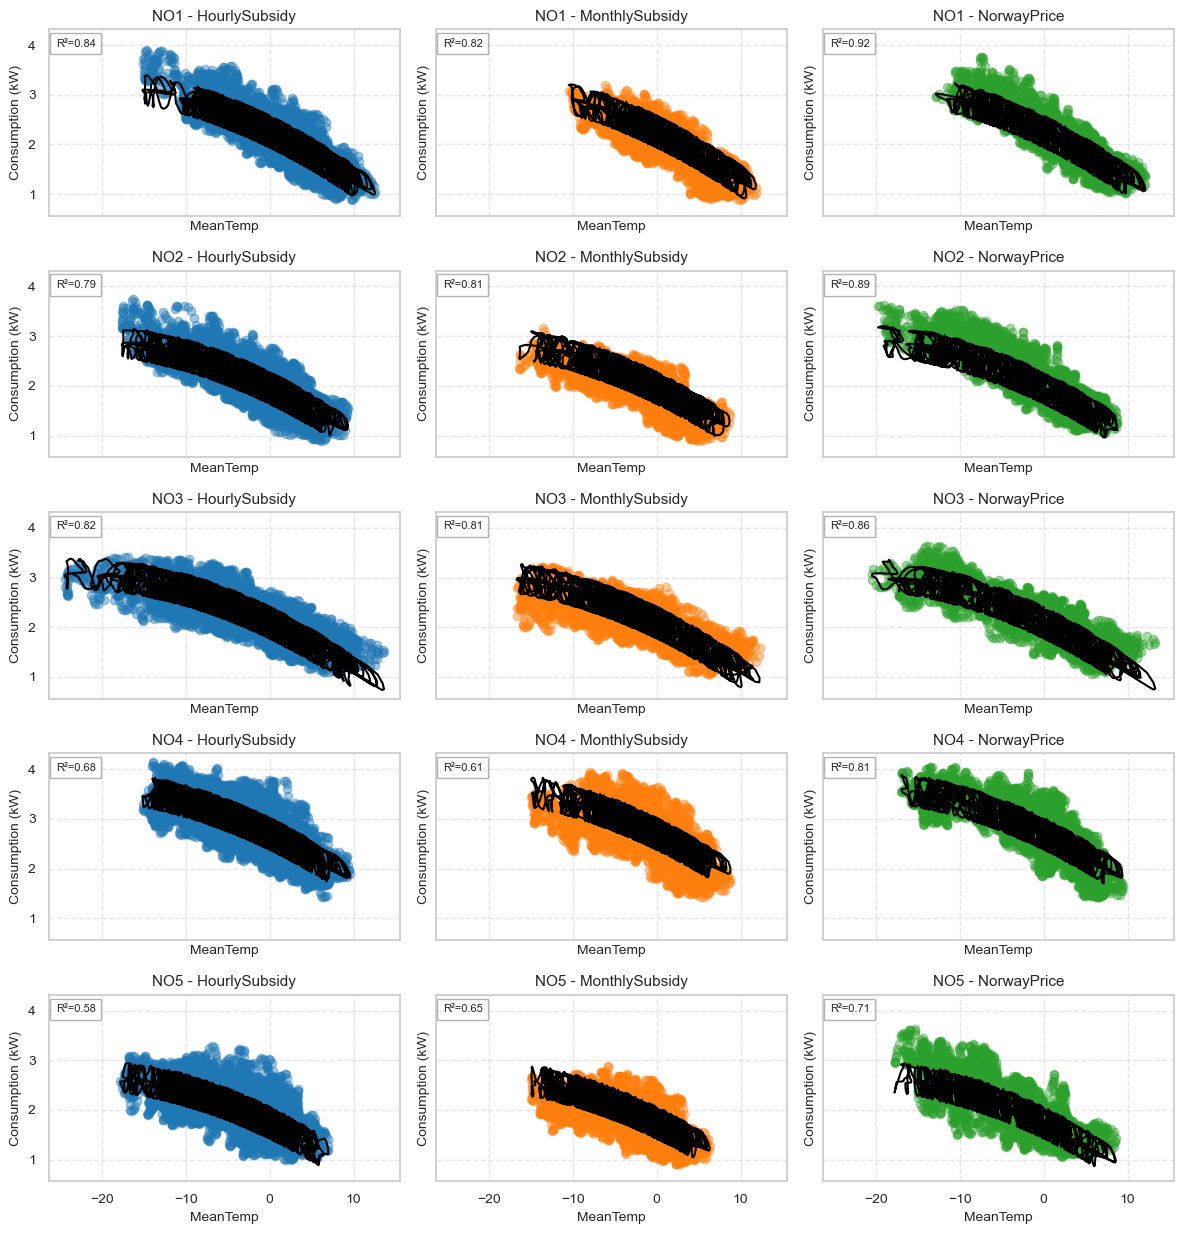

In [30]:

df_model = df_Norge.dropna().copy()
df_model['date'] = pd.to_datetime(df_model['date'])
df_model['MeanTemp_sq'] = df_model['MeanTemp'] ** 2
df_model['is_weekend'] = df_model['date'].dt.weekday >= 5
df_model['weekday'] = df_model['date'].dt.weekday

# --- Combined OLS model for all zones ---
formula = 'Consumption_per_household ~ MeanTemp +MeanTemp_sq + is_weekend + C(weekday)+ C(Zone)+ C(hour) '
best_model = smf.ols(formula, data=df_model).fit()

# Add predicted values
df_model['predicted'] = best_model.predict(df_model)

zones = sorted(hourly_avg['Zone'].unique())
periods = sorted(hourly_avg['Period'].unique())
hour_ticks = [0,5,10,15,20]
period_colors = {periods[0]: 'tab:blue', periods[1]: 'tab:orange', periods[2]: 'tab:green'}

# --- Figure: rows = zones, columns = periods ---
fig, axes = plt.subplots(len(zones), len(periods), figsize=(12, 2.5*len(zones)), sharex=True, sharey=True)
if len(zones) == 1:
    axes = axes[np.newaxis,:]  # Ensure 2D array
if len(periods) == 1:
    axes = axes[:,np.newaxis]

for i, zone in enumerate(zones):
    zone_df = df_model[df_model['Zone']==zone]
    
    for j, period in enumerate(periods):
        ax = axes[i,j]
    
        # Scatter observed points
        obs = df_model[(df_model['Zone']==zone) & (df_model['Period']==period)]
        ax.scatter(obs['MeanTemp'], obs['Consumption_per_household'], alpha=0.4, color=period_colors[period])
        
        # Fit line: use combined model predicted for these points
        ax.plot(obs['MeanTemp'], obs['predicted'], color='black', linestyle='-', label='Fit')
        
        # Compute R² for this zone × period
        if len(obs) > 1:
            R2 = np.corrcoef(obs['Consumption_per_household'], obs['predicted'])[0,1]**2
        else:
            R2 = np.nan
        ax.text(0.02, 0.95, f'R²={R2:.2f}', transform=ax.transAxes,
                ha='left', va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))
        
        ax.set_xlabel('MeanTemp')
        ax.set_ylabel('Consumption (kW)')
        ax.set_title(f'{zone} - {period}')
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 16. Use of the Best Model (Baseline) and Analysis of Residuals
The table below shows a summary of the Model used in the paper

In [31]:

df_model['residual'] = best_model.resid

# --- Step 2: Compute control-zone residual per period ---
treatment_zones = ['NO1','NO2','NO5']
control_zones   = ['NO3','NO4']

control_resid = df_model[df_model['Zone'].isin(control_zones)].groupby('Period')['residual'].mean().to_dict()

# Adjust residuals for treatment zones by subtracting control mean
def adjust_residual(row):
    if row['Zone'] in treatment_zones:
        return row['residual'] - control_resid.get(row['Period'], 0)
    else:
        return row['residual']

df_model['resid_adjusted'] = df_model.apply(adjust_residual, axis=1)

# --- Step 3: OLS per treatment zone, adjusted residuals vs policy period ---
policy_results = {}

for zone in treatment_zones:
    df_zone = df_model[df_model['Zone'] == zone]
    model = smf.ols('resid_adjusted ~ C(Period)', data=df_zone).fit()
    policy_results[zone] = model
    print(f"\n=== Policy Effect Test for Zone {zone} ===")
    print(model.summary())

# --- Settings ---
treatment_zones = ['NO1','NO2','NO5']
periods = sorted(df['Period'].unique())  # ensure consistent order
zone_colors = ['tab:blue', 'tab:orange', 'tab:green']  # one color per treatment zone
bar_width = 0.2
baseline_period = 'HourlySubsidy'  



=== Policy Effect Test for Zone NO1 ===
                            OLS Regression Results                            
Dep. Variable:         resid_adjusted   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     388.6
Date:                Tue, 12 May 2026   Prob (F-statistic):          1.81e-165
Time:                        12:27:49   Log-Likelihood:                 2563.6
No. Observations:               15832   AIC:                            -5121.
Df Residuals:                   15829   BIC:                            -5098.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

### 17. Plot showing Percentage change in electricity consumption in the treatment zones (Used in Paper)

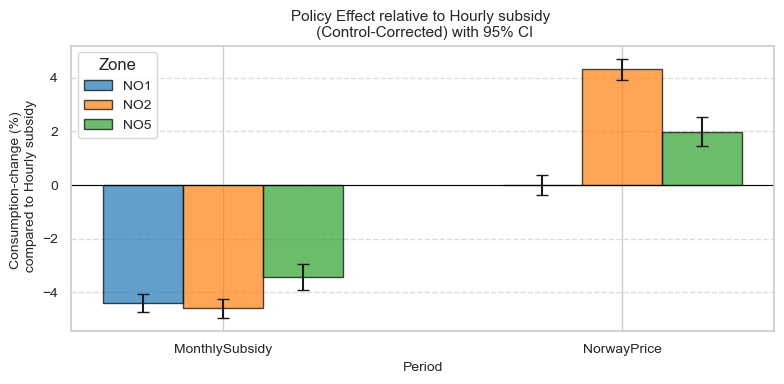

In [32]:
plt.figure(figsize=(8,4))

for i, zone in enumerate(treatment_zones):
    # Extract OLS results for this zone
    model = policy_results[zone]
    
    # Get coefficient estimates and confidence intervals
    coefs = model.params
    conf = model.conf_int()
    
    # Compute effect relative to baseline period
    # 'C(Period)[T.<period>]' corresponds to difference from baseline
    pct_effect = []
    lower_err = []
    upper_err = []
    
    for period in plot_periods:
        term = f'C(Period)[T.{period}]'
        if term in coefs.index:
            effect = coefs[term]
            lower, upper = conf.loc[term]
        else:
            effect = 0.0  # baseline period
            lower, upper = 0.0, 0.0
        
        # Convert to % of baseline consumption
        baseline_mean = df_model[(df_model['Zone']==zone) & (df_model['Period']==baseline_period)]['Consumption_per_household'].mean()
        pct_effect.append(100 * effect / baseline_mean)
        lower_err.append(100 * (effect - lower) / baseline_mean)
        upper_err.append(100 * (upper - effect) / baseline_mean)
    
    # X positions for grouped bars
    x = np.arange(len(plot_periods)) + i * bar_width
    
    # Plot bars with error bars
    plt.bar(x, pct_effect, width=bar_width, color=zone_colors[i], label=zone,
            yerr=[lower_err, upper_err], capsize=4, edgecolor='black', alpha=0.7)

# Formatting
plt.xticks(np.arange(len(plot_periods)) + bar_width, plot_periods)
plt.ylabel('Consumption-change (%) \n compared to Hourly subsidy')
plt.xlabel('Period')
plt.title('Policy Effect relative to Hourly subsidy \n (Control-Corrected) with 95% CI')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Zone')
plt.tight_layout()
plt.savefig("Policy.png", dpi=300)
plt.show()